# 🦟 Análise de Séries Temporais – Arboviroses em Serra/ES
## Projeto Integrador III – Ciência de Dados · FAESA
**Integrantes:** Emanoel Vitor · Luis Felipe · Natalia Pianca · Alessandro Girondoli · Rogeres José  
**Doenças:** Dengue (A90) · Zika (A928) · Chikungunya (A920)  
**Período:** 2015–2023 · **Município:** Serra/ES (IBGE: 3205069)  

---
> **Nota sobre os dados:** Este notebook tenta carregar os microdados reais do SINAN via `pysus`.  
> Caso o download falhe (sem internet, servidor indisponível etc.), o notebook entra automaticamente  
> em modo de **dados simulados** e avisa claramente em cada célula e gráfico.

---
## Seção 0 · Instalação de dependências

In [1]:
# Instale as dependências necessárias (execute uma vez)
# !pip install pysus pandas numpy matplotlib plotly statsmodels scipy --quiet

---
## Seção 1 · Imports e configuração global

In [31]:
import numpy as np
import pandas as pd
from collections import defaultdict
import math
import json
import re
import unicodedata
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.express as px
import folium
from pathlib import Path
from difflib import get_close_matches
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Constantes do projeto ────────────────────────────────────────────────────
CODIGO_IBGE_SERRA = '320506'   # código usado no SINAN (6 dígitos sem dígito verificador)
ANOS = list(range(2015, 2024))
CORES = {'Dengue': '#E63946', 'Zika': '#457B9D', 'Chikungunya': '#2A9D8F'}
NOMES_MES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

USANDO_DADOS_REAIS = False  # será atualizado na Seção 2
print('✅ Imports OK')

✅ Imports OK


---
## Seção 2 · Carregamento dos dados reais (SINAN/DATASUS via pysus)

O notebook tenta baixar automaticamente os microdados do SINAN.  
Se falhar, cai no modo simulado e exibe um aviso claro.

In [3]:
import urllib.request, ssl

ssl_ctx = ssl.create_default_context()
ssl_ctx.check_hostname = False
ssl_ctx.verify_mode = ssl.CERT_NONE

# Lista o que existe na pasta de malhas do ES
urls = [
    'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/UFs/ES/',
    'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022/bairros/shp/UF/ES_bairros_CD2022.zip',
]

for url in urls:
    print(f'\n🔍 {url}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, context=ssl_ctx, timeout=15) as r:
            raw = r.read()
            try:
                import gzip
                raw = gzip.decompress(raw)
            except:
                pass
            texto = raw.decode('utf-8', errors='ignore')
            # Extrai só os nomes de arquivo
            import re
            arquivos = re.findall(r'href="([^"]+\.zip)"', texto, re.IGNORECASE)
            for a in arquivos:
                print(f'   {a}')
    except Exception as e:
        print(f'❌ {e}')


🔍 https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/UFs/ES/
   ES_Mesorregioes_2022.zip
   ES_Microrregioes_2022.zip
   ES_Municipios_2022.zip
   ES_RG_Imediatas_2022.zip
   ES_RG_Intermediarias_2022.zip
   ES_UF_2022.zip

🔍 https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022/bairros/shp/UF/ES_bairros_CD2022.zip


In [4]:
def baixar_infodengue(geocode, doenca_code, label, anos):
    """
    Baixa dados semanais do InfoDengue (Fiocruz) e agrega por mês.
    geocode: código IBGE do município (Serra/ES = 3205002)
    doenca_code: 'dengue', 'zika', 'chikungunya'
    """
    import urllib.request, json

    print(f'  ⬇️  Baixando {label}...')
    base = 'https://info.dengue.mat.br/api/alertcity'

    partes = []
    for ano in anos:
        url = (f'{base}?geocode={geocode}'
               f'&disease={doenca_code}'
               f'&format=json'
               f'&ew_start=1'
               f'&ew_end=53'
               f'&ey_start={ano}'
               f'&ey_end={ano}')
        try:
            with urllib.request.urlopen(url, timeout=30) as r:
                dados = json.loads(r.read().decode())
            if dados:
                partes.extend(dados)
                print(f'     ✅ {label} {ano}: {len(dados)} semanas')
            else:
                print(f'     ⚠️  {label} {ano}: sem dados')
        except Exception as ex:
            print(f'     ⚠️  {label} {ano}: {ex}')

    if not partes:
        raise RuntimeError(f'Nenhum dado obtido para {label}')

    df = pd.DataFrame(partes)

    # data_iniSE vem em milissegundos — converte corretamente
    df['data'] = pd.to_datetime(df['data_iniSE'], unit='ms')
    df['ano']  = df['data'].dt.year
    df['mes']  = df['data'].dt.month
    df['doenca'] = label

    # Agrega casos por mês (soma das semanas epidemiológicas do mês)
    mensal = (df.groupby(['ano', 'mes', 'doenca'])['casos']
                .sum()
                .reset_index())
    mensal['casos'] = mensal['casos'].fillna(0).astype(int)

    print(f'     ✅ {label}: {len(mensal)} meses | {df["data"].min().date()} → {df["data"].max().date()}')
    return mensal


def gerar_dados_simulados():
    """Fallback: gera série mensal realista para fins didáticos."""
    np.random.seed(42)
    idx = pd.date_range('2015-01', periods=9*12, freq='MS')

    def serie(base, amp, trend, ruido, pico=2):
        t = np.arange(len(idx))
        s = base + trend*t + amp*np.sin(2*np.pi*(t-pico)/12) + np.random.normal(0, ruido, len(t))
        return np.maximum(0, s).astype(int)

    frames = []
    for doenca, (base, amp, trend, ruido, pico) in {
        'Dengue':      (300, 250, 1.8, 40, 2),
        'Zika':        (60,  80,  0.3, 15, 2),
        'Chikungunya': (80,  100, 0.9, 20, 3),
    }.items():
        casos = serie(base, amp, trend, ruido, pico)
        for i, dt in enumerate(idx):
            frames.append({'data': dt, 'ano': dt.year, 'mes': dt.month,
                           'doenca': doenca, 'casos': casos[i]})
    return pd.DataFrame(frames)


# ── Tentativa de download real via InfoDengue ────────────────────────────────
GEOCODE_SERRA = 3205002  # Serra/ES — código IBGE correto

try:
    print('🔄 Tentando baixar dados reais do InfoDengue (Fiocruz)...')
    mapa = [
        ('dengue',        'Dengue'),
        ('zika',          'Zika'),
        ('chikungunya',   'Chikungunya'),
    ]
    partes = []
    for code, label in mapa:
        partes.append(baixar_infodengue(GEOCODE_SERRA, code, label, ANOS))

    df_casos = pd.concat(partes, ignore_index=True)

    # Preenche meses sem casos com zero (série contínua)
    idx_completo = pd.date_range('2015-01', '2023-12', freq='MS')
    linhas = []
    for doenca in ['Dengue', 'Zika', 'Chikungunya']:
        for dt in idx_completo:
            sub = df_casos[(df_casos['doenca']==doenca) &
                           (df_casos['ano']==dt.year) &
                           (df_casos['mes']==dt.month)]
            casos = int(sub['casos'].sum()) if len(sub) else 0
            linhas.append({'data': dt, 'ano': dt.year, 'mes': dt.month,
                           'doenca': doenca, 'casos': casos})

    df_casos = pd.DataFrame(linhas)
    df_casos['data'] = pd.to_datetime(df_casos['data'])

    USANDO_DADOS_REAIS = True
    SUFIXO_TITULO = '<br><sup>Fonte: InfoDengue/Fiocruz – Serra/ES</sup>'
    AVISO_TITULO  = '\nFonte: InfoDengue/Fiocruz'
    print(f'\n✅ DADOS REAIS carregados com sucesso! {len(df_casos)} registros mensais.')

except Exception as e:
    print(f'\n⚠️  Falha no download: {e}')
    print('   → Modo DADOS SIMULADOS ativado (para fins didáticos)')
    df_casos = gerar_dados_simulados()
    USANDO_DADOS_REAIS = False
    SUFIXO_TITULO = '<br><sup>⚠️ DADOS SIMULADOS – substitua pelos dados reais do SINAN</sup>'
    AVISO_TITULO  = '\n⚠️ DADOS SIMULADOS'

print(f'\nDataset: {len(df_casos)} linhas | {df_casos["data"].min().date()} → {df_casos["data"].max().date()}')
print(f'Dados reais: {USANDO_DADOS_REAIS}')
df_casos.head(6)

🔄 Tentando baixar dados reais do InfoDengue (Fiocruz)...
  ⬇️  Baixando Dengue...
     ✅ Dengue 2015: 52 semanas
     ✅ Dengue 2016: 52 semanas
     ✅ Dengue 2017: 52 semanas
     ✅ Dengue 2018: 52 semanas
     ✅ Dengue 2019: 52 semanas
     ✅ Dengue 2020: 53 semanas
     ✅ Dengue 2021: 52 semanas
     ✅ Dengue 2022: 52 semanas
     ✅ Dengue 2023: 52 semanas
     ✅ Dengue: 108 meses | 2015-01-04 → 2023-12-24
  ⬇️  Baixando Zika...
     ✅ Zika 2015: 52 semanas
     ✅ Zika 2016: 52 semanas
     ✅ Zika 2017: 52 semanas
     ✅ Zika 2018: 52 semanas
     ✅ Zika 2019: 52 semanas
     ✅ Zika 2020: 53 semanas
     ✅ Zika 2021: 52 semanas
     ✅ Zika 2022: 52 semanas
     ✅ Zika 2023: 52 semanas
     ✅ Zika: 108 meses | 2015-01-04 → 2023-12-24
  ⬇️  Baixando Chikungunya...
     ✅ Chikungunya 2015: 52 semanas
     ✅ Chikungunya 2016: 52 semanas
     ✅ Chikungunya 2017: 52 semanas
     ✅ Chikungunya 2018: 52 semanas
     ✅ Chikungunya 2019: 52 semanas
     ✅ Chikungunya 2020: 53 semanas
     ✅ Ch

,data,ano,mes,doenca,casos
0,2015-01-01,2015,1,Dengue,174
1,2015-02-01,2015,2,Dengue,115
2,2015-03-01,2015,3,Dengue,279
3,2015-04-01,2015,4,Dengue,425
4,2015-05-01,2015,5,Dengue,779
5,2015-06-01,2015,6,Dengue,498


---
## Seção 3 · Estatísticas descritivas

In [5]:
resumo = (df_casos.groupby('doenca')['casos']
          .agg(total='sum', media_mensal='mean', mediana='median',
               maximo='max', desvio_padrao='std')
          .round(1))

fonte = 'SINAN/DATASUS (dados reais)' if USANDO_DADOS_REAIS else 'DADOS SIMULADOS'
print(f'Fonte: {fonte}')
print(f'Período: 2015–2023 | Município: Serra/ES\n')
print(resumo.to_string())

Fonte: SINAN/DATASUS (dados reais)
Período: 2015–2023 | Município: Serra/ES

             total  media_mensal  mediana  maximo  desvio_padrao
doenca                                                          
Chikungunya   1092          10.1      4.0      95           17.8
Dengue       60067         556.2    124.5    5659         1029.9
Zika           608           5.6      1.0      66           11.1


---
## Seção 4 · Séries temporais brutas (Plotly interativo)

In [6]:
fig = go.Figure()
for doenca, cor in CORES.items():
    d = df_casos[df_casos['doenca'] == doenca].sort_values('data')
    fig.add_trace(go.Scatter(
        x=d['data'], y=d['casos'],
        mode='lines', name=doenca,
        line=dict(color=cor, width=2),
        hovertemplate='%{x|%b/%Y}<br>Casos: %{y}<extra>' + doenca + '</extra>'
    ))

fig.update_layout(
    title='Notificações mensais de arboviroses – Serra/ES (2015–2023)' + SUFIXO_TITULO,
    xaxis_title='Mês', yaxis_title='Casos notificados',
    hovermode='x unified', template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=450
)
fig.show()

---
## Seção 5 · Decomposição das séries temporais (statsmodels)

A decomposição clássica separa cada série em três componentes:
- **Tendência** – direção geral ao longo dos anos
- **Sazonalidade** – padrão que se repete anualmente
- **Resíduo** – variação não explicada pelos dois anteriores

Usamos o modelo **aditivo** (`model='additive'`), adequado quando a amplitude sazonal não cresce proporcionalmente à tendência.

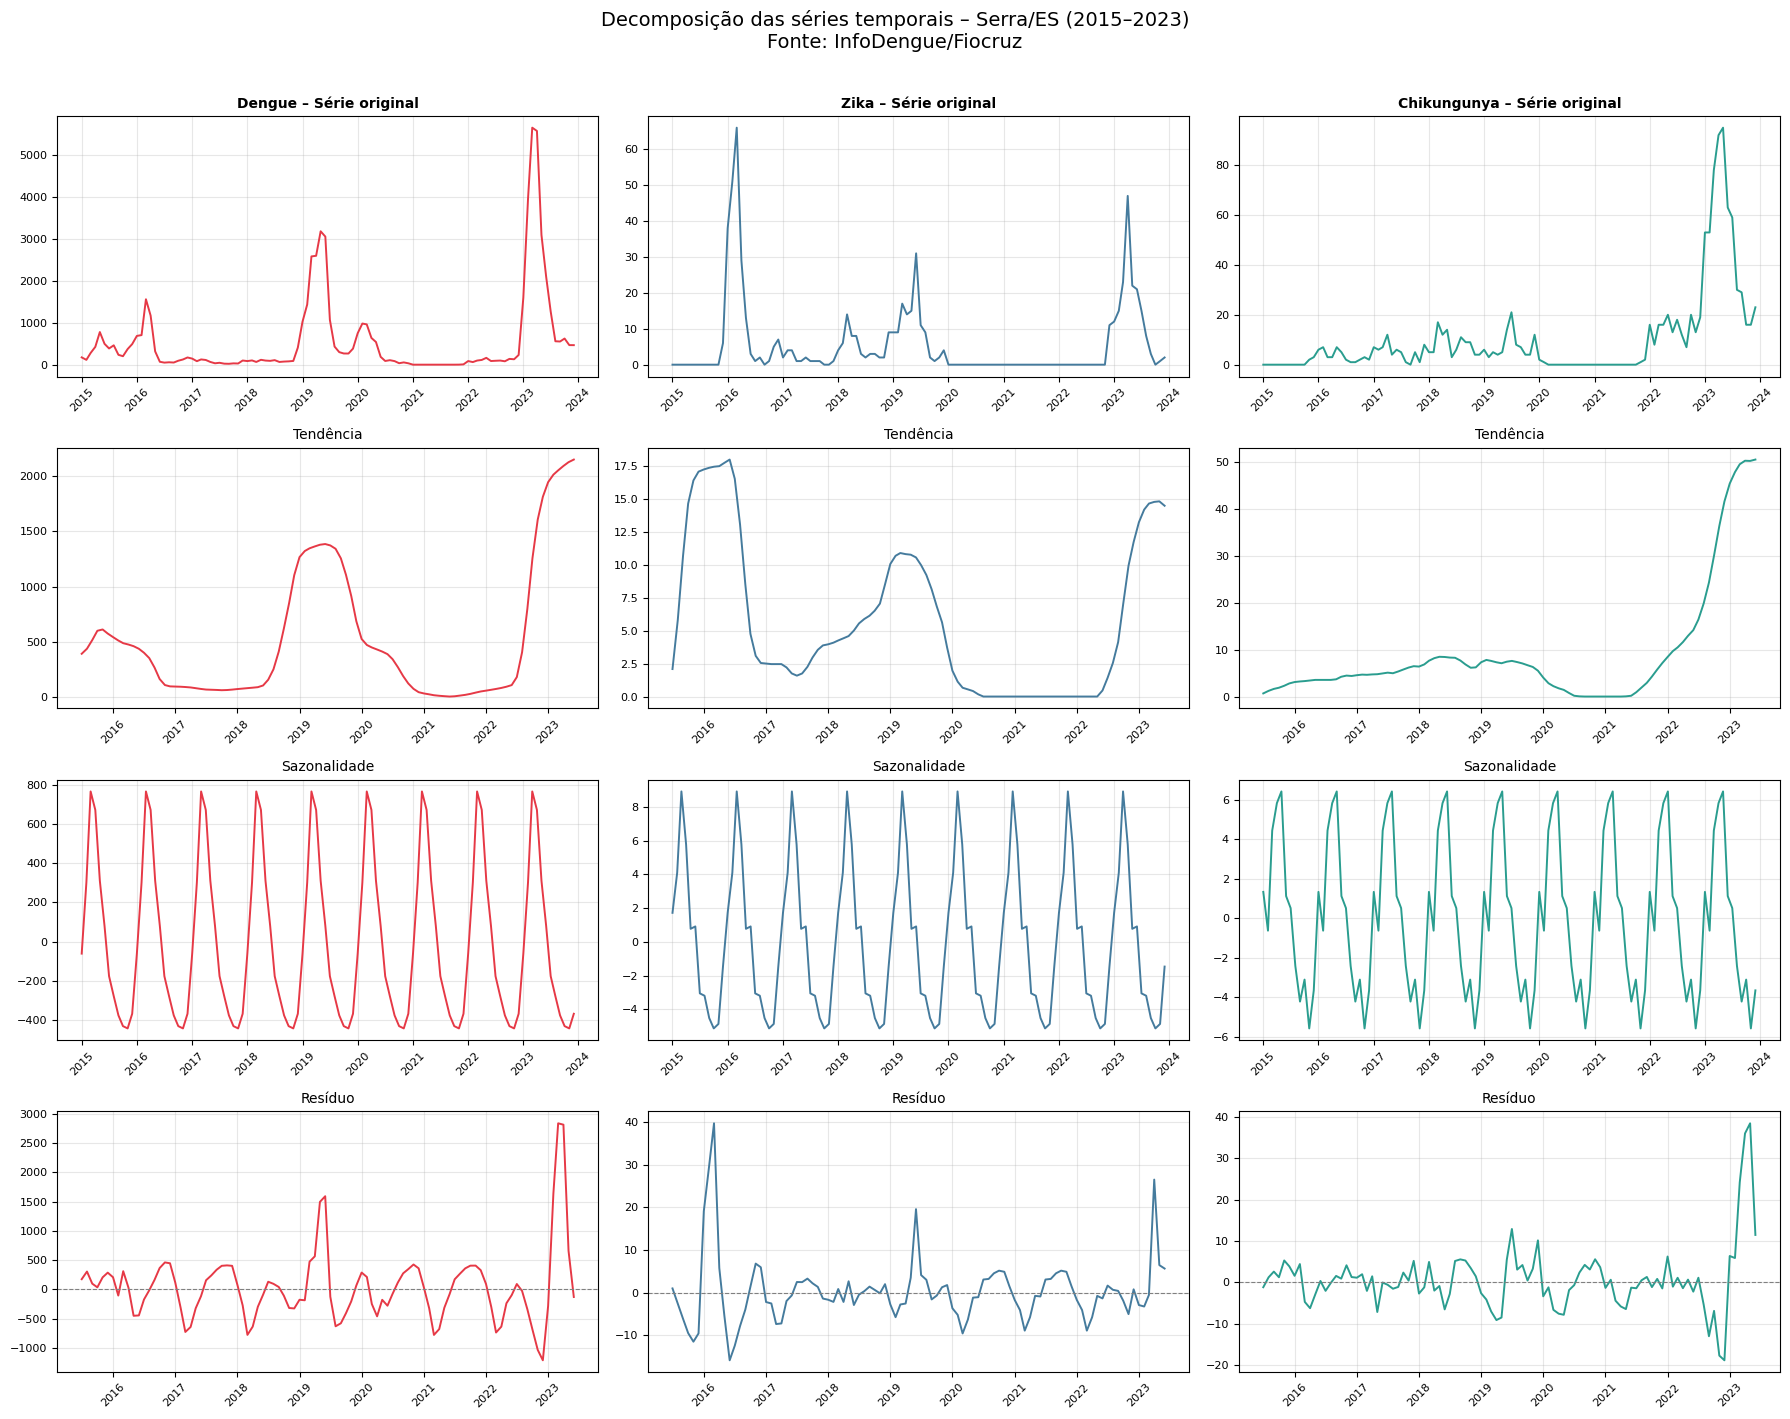

✅ Figura salva: decomposicao_series.png


In [7]:
doenças = ['Dengue', 'Zika', 'Chikungunya']
decomposições = {}

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 14))
suptitle = f'Decomposição das séries temporais – Serra/ES (2015–2023){AVISO_TITULO}'
fig.suptitle(suptitle, fontsize=14, y=1.01)

titulos_linhas = ['Série original', 'Tendência', 'Sazonalidade', 'Resíduo']
cores_mpl = {'Dengue': '#E63946', 'Zika': '#457B9D', 'Chikungunya': '#2A9D8F'}

for col, doenca in enumerate(doenças):
    serie = (df_casos[df_casos['doenca'] == doenca]
             .sort_values('data')
             .set_index('data')['casos']
             .asfreq('MS'))

    dec = seasonal_decompose(serie, model='additive', period=12)
    decomposições[doenca] = dec
    cor = cores_mpl[doenca]

    componentes = [serie, dec.trend, dec.seasonal, dec.resid]
    for row, (comp, titulo) in enumerate(zip(componentes, titulos_linhas)):
        ax = axes[row, col]
        ax.plot(comp.index, comp.values, color=cor, linewidth=1.4)
        ax.set_title(f'{doenca} – {titulo}' if row == 0 else titulo,
                     fontsize=10, fontweight='bold' if row == 0 else 'normal')
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, alpha=0.3)
        if row == 3:
            ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('decomposicao_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: decomposicao_series.png')

---
## Seção 6 · Padrão sazonal médio por mês

In [8]:
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=[f'<b>{d}</b>' for d in doenças],
                    shared_yaxes=False)

for col, doenca in enumerate(doenças, start=1):
    media_mes = (df_casos[df_casos['doenca'] == doenca]
                 .groupby('mes')['casos'].mean().round(1))
    cor = CORES[doenca]
    fig.add_trace(
        go.Bar(x=NOMES_MES, y=media_mes.values,
               name=doenca, marker_color=cor,
               hovertemplate='%{x}: %{y:.0f} casos/mês<extra></extra>',
               showlegend=False),
        row=1, col=col
    )
    pico = media_mes.idxmax()
    fig.add_annotation(
        x=NOMES_MES[pico - 1], y=media_mes[pico],
        text=f'Pico: {NOMES_MES[pico-1]}', showarrow=True,
        arrowhead=2, ax=0, ay=-30, font=dict(size=10, color=cor),
        xref=f'x{col}', yref=f'y{col}'
    )

fig.update_layout(
    title='Média de casos por mês (2015–2023) – sazonalidade histórica' + SUFIXO_TITULO,
    template='plotly_white', height=420,
    yaxis_title='Média de casos'
)
fig.show()

---
## Seção 7 · Evolução anual de casos (tendência)

In [9]:
anual = df_casos.groupby(['ano', 'doenca'])['casos'].sum().reset_index()

fig = px.line(anual, x='ano', y='casos', color='doenca',
              markers=True,
              color_discrete_map=CORES,
              labels={'ano': 'Ano', 'casos': 'Total de casos', 'doenca': 'Doença'},
              title='Total anual de casos notificados – Serra/ES (2015–2023)' + SUFIXO_TITULO)
fig.update_traces(line_width=2.5, marker_size=8)
fig.update_layout(template='plotly_white', height=420, hovermode='x unified')
fig.show()

---
## Seção 8 · Heatmap de sazonalidade (ano × mês)

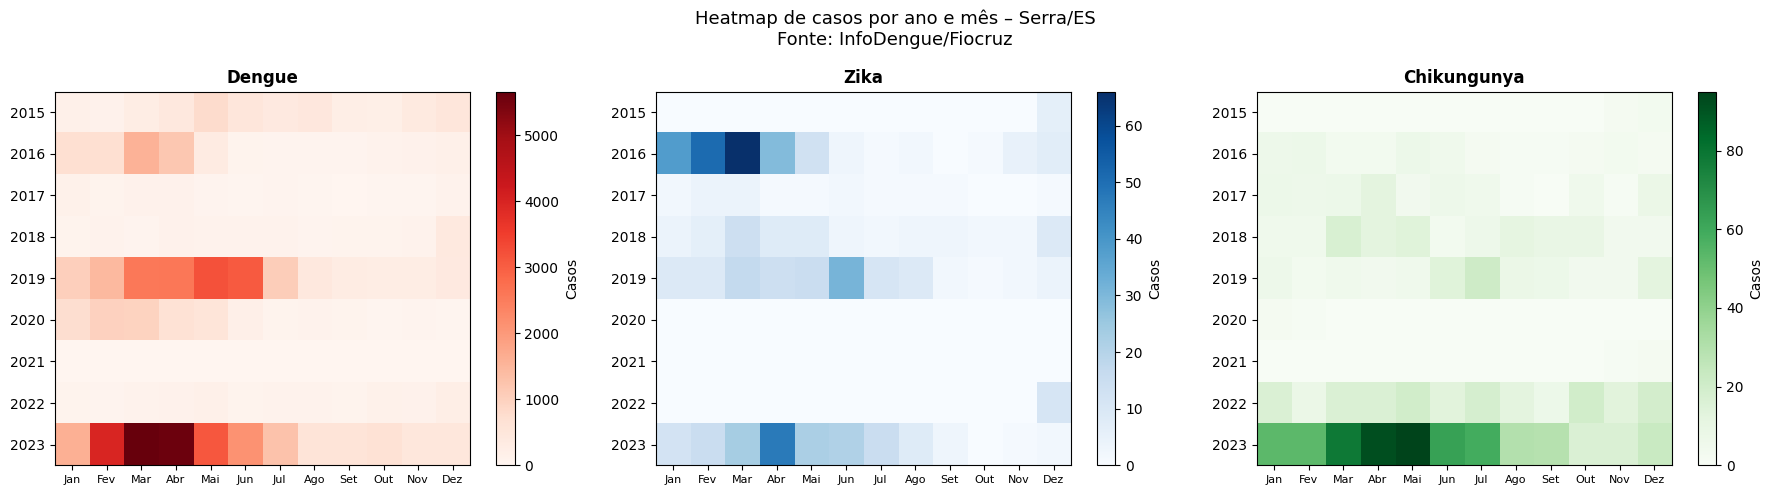

✅ Figura salva: heatmap_sazonalidade.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Heatmap de casos por ano e mês – Serra/ES{AVISO_TITULO}', fontsize=13)

for ax, doenca in zip(axes, doenças):
    pivot = (df_casos[df_casos['doenca'] == doenca]
             .pivot_table(index='ano', columns='mes', values='casos', aggfunc='sum'))
    pivot.columns = NOMES_MES[:len(pivot.columns)]

    cmap = {'Dengue': 'Reds', 'Zika': 'Blues', 'Chikungunya': 'Greens'}[doenca]
    im = ax.imshow(pivot.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontsize=8)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    ax.set_title(doenca, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Casos')

plt.tight_layout()
plt.savefig('heatmap_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: heatmap_sazonalidade.png')

---
## Seção 9 · Componente sazonal extraído pela decomposição

In [11]:
fig = go.Figure()
for doenca in doenças:
    sazonal_ciclo = decomposições[doenca].seasonal.iloc[:12]
    fig.add_trace(go.Scatter(
        x=NOMES_MES,
        y=sazonal_ciclo.values,
        mode='lines+markers',
        name=doenca,
        line=dict(color=CORES[doenca], width=2.5),
        marker=dict(size=8)
    ))

fig.add_hline(y=0, line_dash='dash', line_color='gray', line_width=1)
fig.update_layout(
    title='Componente sazonal extraído (statsmodels) – 1 ciclo anual' + SUFIXO_TITULO,
    xaxis_title='Mês', yaxis_title='Efeito sazonal (casos)',
    template='plotly_white', height=420,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()

---
## Seção 10 · Conclusões – Séries Temporais

> **Se estiver usando dados reais:** atualize as conclusões abaixo com os valores reais observados.

In [12]:
print('=' * 65)
print('CONCLUSÕES – SÉRIES TEMPORAIS · Serra/ES (2015–2023)')
print('=' * 65)
for doenca in doenças:
    total = df_casos[df_casos['doenca']==doenca]['casos'].sum()
    media = df_casos[df_casos['doenca']==doenca]['casos'].mean()
    pico_mes = (df_casos[df_casos['doenca']==doenca]
                .groupby('mes')['casos'].mean().idxmax())
    trend = decomposições[doenca].trend.dropna()
    variacao_trend = trend.iloc[-1] - trend.iloc[0]
    direcao = '↑ crescente' if variacao_trend > 0 else '↓ decrescente'
    print(f'\n{doenca}:')
    print(f'  Total no período : {total:,} casos')
    print(f'  Média mensal     : {media:.1f} casos/mês')
    print(f'  Mês de pico      : {NOMES_MES[pico_mes-1]}')
    print(f'  Tendência        : {direcao} ({variacao_trend:+.0f} casos entre início e fim da tendência)')
print(f'\nFonte: {"SINAN/DATASUS – dados reais" if USANDO_DADOS_REAIS else "⚠️ DADOS SIMULADOS"}')

CONCLUSÕES – SÉRIES TEMPORAIS · Serra/ES (2015–2023)

Dengue:
  Total no período : 60,067 casos
  Média mensal     : 556.2 casos/mês
  Mês de pico      : Mar
  Tendência        : ↑ crescente (+1762 casos entre início e fim da tendência)

Zika:
  Total no período : 608 casos
  Média mensal     : 5.6 casos/mês
  Mês de pico      : Mar
  Tendência        : ↑ crescente (+12 casos entre início e fim da tendência)

Chikungunya:
  Total no período : 1,092 casos
  Média mensal     : 10.1 casos/mês
  Mês de pico      : Mai
  Tendência        : ↑ crescente (+50 casos entre início e fim da tendência)

Fonte: SINAN/DATASUS – dados reais


---
## 🌧️ Correlação Climática

### Seção 11 · Geração dos dados climáticos (INMET)

Fonte ideal: [INMET – Banco de Dados Meteorológicos](https://bdmep.inmet.gov.br/)  
Estação mais próxima de Serra/ES: **Vitória (A612)**  

**Para usar dados reais do INMET:**  
1. Acesse https://bdmep.inmet.gov.br  
2. Selecione a estação **A612 – Vitória/ES**  
3. Período: 01/01/2015 a 31/12/2023  
4. Variáveis: Precipitação Total e Temperatura Média  
5. Salve como CSV e substitua o DataFrame `df_clima` abaixo

In [13]:
# ── Tentativa de leitura de dados reais do INMET (CSV exportado) ─────────────
# Se você tiver o arquivo, descomente e ajuste o caminho:
# import os
# if os.path.exists('inmet_vitoria_2015_2023.csv'):
#     df_inmet = pd.read_csv('inmet_vitoria_2015_2023.csv', sep=';', encoding='latin1')
#     # ajuste os nomes das colunas conforme o arquivo real
#     df_inmet['data'] = pd.to_datetime(df_inmet['Data'], dayfirst=True)
#     df_clima = (df_inmet.groupby([df_inmet['data'].dt.year.rename('ano'),
#                                   df_inmet['data'].dt.month.rename('mes')])
#                 .agg(precip_mm=('Precipitacao Total (mm)', 'sum'),
#                      temp_c=('Temperatura Media (C)', 'mean'))
#                 .reset_index())
#     CLIMA_REAL = True
# else:

# ── Dados climáticos simulados (sazonalidade realista para Vitória/ES) ───────
np.random.seed(7)
idx_clima = pd.date_range('2015-01', periods=9*12, freq='MS')
t = np.arange(len(idx_clima))

# Vitória: chuvas concentradas em nov–mar, seco em jun–ago
precip = (180 + 150*np.sin(2*np.pi*(t - 1)/12) +
          np.random.normal(0, 30, len(t))).clip(0)
temp   = (24  + 4  *np.sin(2*np.pi*(t - 1)/12) +
          np.random.normal(0, 0.5, len(t)))

df_clima = pd.DataFrame({
    'data':      idx_clima,
    'ano':       idx_clima.year,
    'mes':       idx_clima.month,
    'precip_mm': precip.round(1),
    'temp_c':    temp.round(1),
})
CLIMA_REAL = False
print(f'Dados climáticos: {"reais" if CLIMA_REAL else "simulados (substitua pelo CSV do INMET)"}')
df_clima.head()

Dados climáticos: simulados (substitua pelo CSV do INMET)


,data,ano,mes,precip_mm,temp_c
0,2015-01-01,2015,1,155.7,22.9
1,2015-02-01,2015,2,166.0,23.8
2,2015-03-01,2015,3,256.0,25.9
3,2015-04-01,2015,4,322.1,27.6
4,2015-05-01,2015,5,306.3,28.5


### Seção 12 · Visualização das séries climáticas

In [14]:
aviso_clima = '' if CLIMA_REAL else '<br><sup>⚠️ Dados climáticos simulados</sup>'

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Precipitação mensal (mm)', 'Temperatura média (°C)'],
                    vertical_spacing=0.08)

fig.add_trace(go.Bar(x=df_clima['data'], y=df_clima['precip_mm'],
                     name='Precipitação', marker_color='#4CC9F0',
                     hovertemplate='%{x|%b/%Y}: %{y:.0f} mm<extra></extra>'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_clima['data'], y=df_clima['temp_c'],
                          name='Temperatura', line=dict(color='#F77F00', width=2),
                          hovertemplate='%{x|%b/%Y}: %{y:.1f}°C<extra></extra>'), row=2, col=1)

fig.update_layout(title='Variáveis climáticas – Vitória/ES (estação INMET A612)' + aviso_clima,
                  template='plotly_white', height=500, showlegend=False)
fig.show()

### Seção 13 · Correlação temporal com precipitação e temperatura (Pearson / Spearman)

In [15]:
# Merge casos × clima por ano e mês
doenças_lista = ['Dengue', 'Zika', 'Chikungunya']
df_pivot = (df_casos.pivot_table(index=['ano','mes'], columns='doenca',
                                  values='casos', aggfunc='sum')
            .reset_index())
df_corr = df_pivot.merge(df_clima[['ano','mes','precip_mm','temp_c']], on=['ano','mes'])

# ── Matrizes de correlação ───────────────────────────────────────────────────
vars_clima = ['precip_mm', 'temp_c']
labels_clima = ['Precip. (mm)', 'Temp. (°C)']

pearson_matrix  = np.zeros((len(doenças_lista), len(vars_clima)))
spearman_matrix = np.zeros((len(doenças_lista), len(vars_clima)))

print('=' * 60)
print('CORRELAÇÕES · Casos de arboviroses × Clima (2015–2023)')
print('=' * 60)
for i, doenca in enumerate(doenças_lista):
    for j, var in enumerate(vars_clima):
        x = df_corr[doenca].values
        y = df_corr[var].values
        r_p, p_p = stats.pearsonr(x, y)
        r_s, p_s = stats.spearmanr(x, y)
        pearson_matrix[i, j]  = r_p
        spearman_matrix[i, j] = r_s
        sig_p = '***' if p_p < 0.001 else '**' if p_p < 0.01 else '*' if p_p < 0.05 else 'ns'
        sig_s = '***' if p_s < 0.001 else '**' if p_s < 0.01 else '*' if p_s < 0.05 else 'ns'
        print(f'{doenca:14s} × {labels_clima[j]:14s} | '
              f'Pearson r={r_p:+.3f}{sig_p:3s} | Spearman ρ={r_s:+.3f}{sig_s}')
print('\n(*** p<0.001  ** p<0.01  * p<0.05  ns = não significativo)')

CORRELAÇÕES · Casos de arboviroses × Clima (2015–2023)
Dengue         × Precip. (mm)   | Pearson r=+0.281**  | Spearman ρ=+0.185ns
Dengue         × Temp. (°C)     | Pearson r=+0.309**  | Spearman ρ=+0.177ns
Zika           × Precip. (mm)   | Pearson r=+0.220*   | Spearman ρ=+0.151ns
Zika           × Temp. (°C)     | Pearson r=+0.234*   | Spearman ρ=+0.138ns
Chikungunya    × Precip. (mm)   | Pearson r=+0.183ns  | Spearman ρ=+0.044ns
Chikungunya    × Temp. (°C)     | Pearson r=+0.181ns  | Spearman ρ=+0.018ns

(*** p<0.001  ** p<0.01  * p<0.05  ns = não significativo)


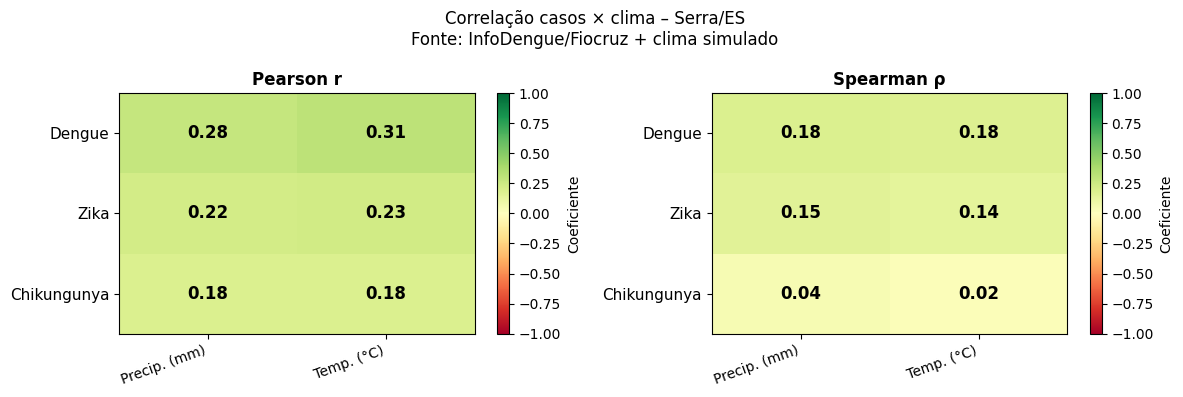

✅ Figura salva: correlacao_climatica.png


In [16]:
# ── Heatmap das correlações ──────────────────────────────────────────────────
aviso_mpl = AVISO_TITULO + (' + clima simulado' if not CLIMA_REAL else '')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Correlação casos × clima – Serra/ES{aviso_mpl}', fontsize=12)

n_d = len(doenças_lista)
n_v = len(vars_clima)

for ax, matrix, titulo in zip(axes, [pearson_matrix, spearman_matrix], ['Pearson r', 'Spearman ρ']):
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n_v));  ax.set_xticklabels(labels_clima, rotation=20, ha='right', fontsize=10)
    ax.set_yticks(range(n_d));  ax.set_yticklabels(doenças_lista, fontsize=11)
    ax.set_title(titulo, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Coeficiente')
    for i in range(n_d):
        for j in range(n_v):
            val = matrix[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if abs(val) > 0.6 else 'black')

plt.tight_layout()
plt.savefig('correlacao_climatica.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: correlacao_climatica.png')

### Seção 14 · Dispersão: casos × variáveis climáticas

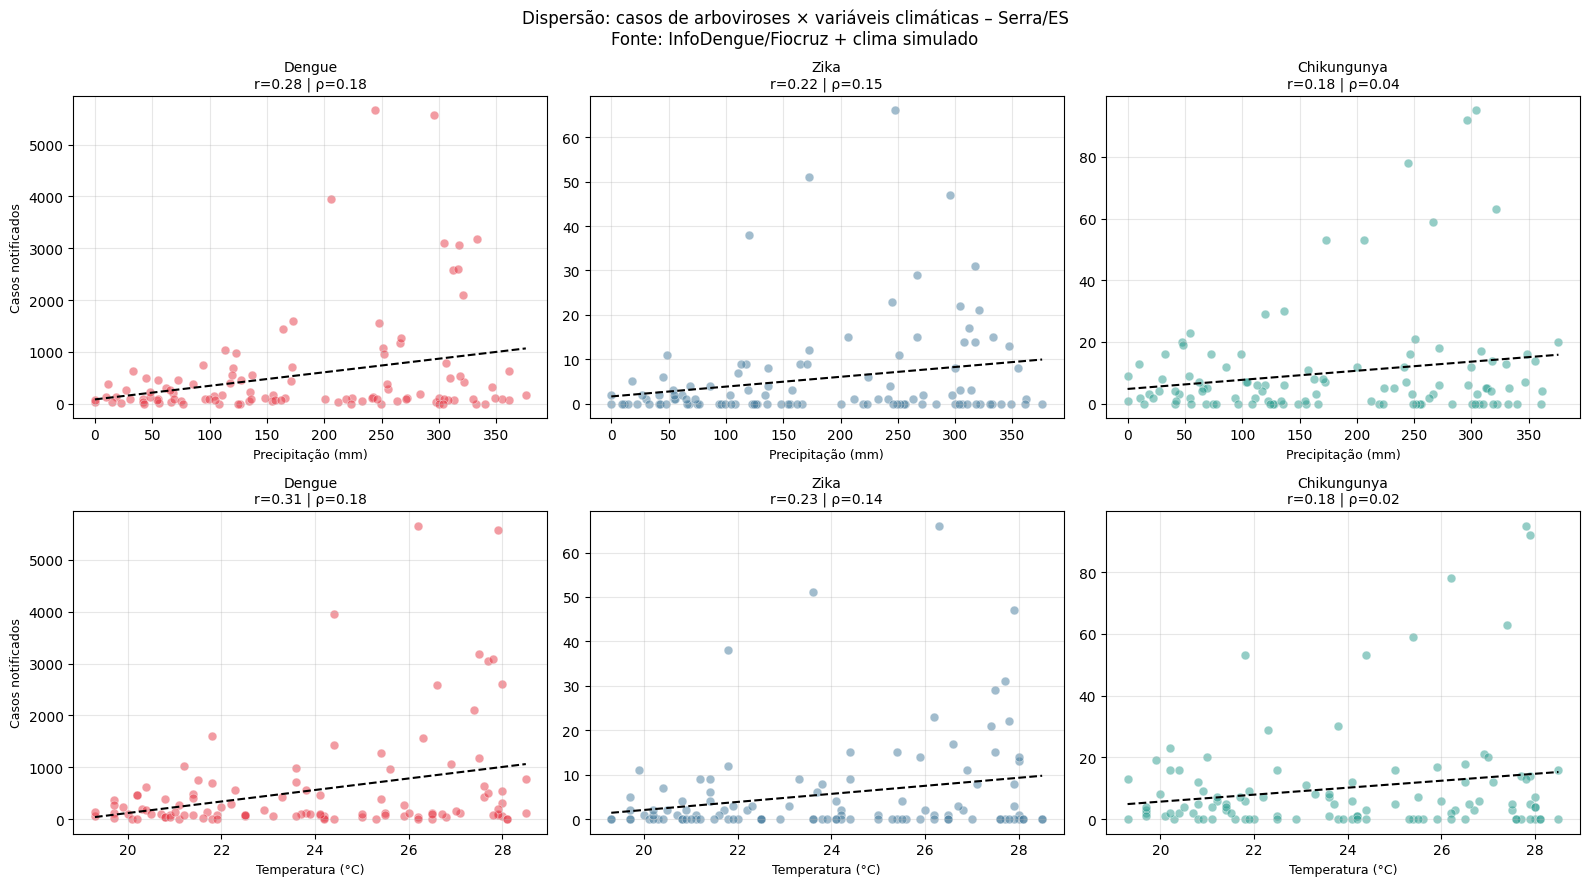

✅ Figura salva: dispersao_casos_clima.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Dispersão: casos de arboviroses × variáveis climáticas – Serra/ES{aviso_mpl}', fontsize=12)

cores_mpl = {'Dengue': '#E63946', 'Zika': '#457B9D', 'Chikungunya': '#2A9D8F'}

for col_idx, doenca in enumerate(doenças_lista):
    cor = cores_mpl[doenca]
    x_casos = df_corr[doenca].values

    for row_idx, (var_col, var_label) in enumerate([('precip_mm', 'Precipitação (mm)'),
                                                    ('temp_c',    'Temperatura (°C)')]):
        ax = axes[row_idx, col_idx]
        y_clima = df_corr[var_col].values

        ax.scatter(y_clima, x_casos, alpha=0.5, color=cor, s=40,
                   edgecolors='white', linewidths=0.5)

        z = np.polyfit(y_clima, x_casos, 1)
        p = np.poly1d(z)
        x_line = np.linspace(y_clima.min(), y_clima.max(), 100)
        ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--')

        r_p, _ = stats.pearsonr(x_casos, y_clima)
        r_s, _ = stats.spearmanr(x_casos, y_clima)
        ax.set_title(f'{doenca}\nr={r_p:.2f} | ρ={r_s:.2f}', fontsize=10)
        ax.set_xlabel(var_label, fontsize=9)
        ax.set_ylabel('Casos notificados' if col_idx == 0 else '', fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dispersao_casos_clima.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: dispersao_casos_clima.png')

### Seção 15 · Identificação dos meses de pico histórico

In [18]:
resultados_pico = []

for doenca in doenças_lista:
    df_d = df_casos[df_casos['doenca'] == doenca].copy()
    media_mes = df_d.groupby('mes')['casos'].mean()
    top3 = media_mes.nlargest(3)

    # Consistência: em quantos anos aquele mês foi o de maior volume?
    pico_por_ano = (df_d.groupby('ano')
                    .apply(lambda g: g.loc[g['casos'].idxmax(), 'mes'],
                           include_groups=False))
    consistencia = pico_por_ano.value_counts()

    for rank, (mes_num, media) in enumerate(top3.items(), start=1):
        resultados_pico.append({
            'Doença':          doenca,
            'Rank':            rank,
            'Mês':             NOMES_MES[mes_num - 1],
            'Nº do mês':       mes_num,
            'Média histórica': round(media, 1),
            'Anos como pico':  consistencia.get(mes_num, 0)
        })

df_picos = pd.DataFrame(resultados_pico)
print('=' * 60)
print('TOP-3 MESES DE PICO HISTÓRICO POR DOENÇA (2015–2023)')
print('=' * 60)
print(df_picos.to_string(index=False))

TOP-3 MESES DE PICO HISTÓRICO POR DOENÇA (2015–2023)
     Doença  Rank Mês  Nº do mês  Média histórica  Anos como pico
     Dengue     1 Mar          3           1259.4               2
     Dengue     2 Abr          4           1195.2               0
     Dengue     3 Mai          5            916.1               2
       Zika     1 Mar          3             13.8               2
       Zika     2 Abr          4             11.0               1
       Zika     3 Fev          2              9.4               1
Chikungunya     1 Mai          5             16.1               2
Chikungunya     2 Abr          4             15.4               1
Chikungunya     3 Mar          3             14.0               1


In [19]:
# ── Visualização dos picos ───────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=[f'<b>{d}</b>' for d in doenças_lista],
                    shared_yaxes=False)

for col_idx, doenca in enumerate(doenças_lista, start=1):
    df_d      = df_casos[df_casos['doenca'] == doenca]
    media_mes = df_d.groupby('mes')['casos'].mean().round(1)
    top3_idx  = media_mes.nlargest(3).index.tolist()
    cor_base  = CORES[doenca]

    bar_cores = ['#FF4444' if m in top3_idx[:1]
                 else '#FF9944' if m in top3_idx[1:2]
                 else '#FFCC44' if m in top3_idx[2:]
                 else cor_base
                 for m in media_mes.index]

    fig.add_trace(go.Bar(
        x=NOMES_MES, y=media_mes.values,
        marker_color=bar_cores, name=doenca,
        showlegend=False,
        hovertemplate='%{x}: %{y:.0f} casos/mês<extra></extra>'
    ), row=1, col=col_idx)

    pico_mes = media_mes.idxmax()
    pico_val = media_mes[pico_mes]
    fig.add_annotation(
        x=NOMES_MES[pico_mes - 1], y=pico_val,
        text=f' {NOMES_MES[pico_mes-1]}',
        showarrow=True, arrowhead=2, ax=0, ay=-35,
        font=dict(size=10, color='#CC0000', family='Arial Black'),
        xref=f'x{col_idx}', yref=f'y{col_idx}'
    )

# Legenda manual
for label, color in [('🥇 1º pico','#FF4444'),('🥈 2º pico','#FF9944'),('🥉 3º pico','#FFCC44')]:
    fig.add_trace(go.Bar(x=[None], y=[None], marker_color=color, name=label, showlegend=True))

fig.update_layout(
    title='Média histórica de casos por mês – picos destacados (2015–2023)' + SUFIXO_TITULO,
    template='plotly_white', height=430, barmode='group',
    legend=dict(orientation='h', y=1.08, x=0.5, xanchor='center')
)
fig.update_yaxes(title_text='Média de casos', row=1, col=1)
fig.show()

---
### Seção 16 · Conclusões – Correlação Climática e Picos Históricos

> **Se estiver usando dados reais:** atualize as conclusões abaixo com os valores reais observados.

In [20]:
print('=' * 65)
print('CONCLUSÕES – CORRELAÇÃO CLIMÁTICA E PICOS HISTÓRICOS')
print('Serra/ES (2015–2023)')
print('=' * 65)

for i, doenca in enumerate(doenças_lista):
    rp_prec = pearson_matrix[i, 0]
    rs_prec = spearman_matrix[i, 0]
    rp_temp = pearson_matrix[i, 1]
    rs_temp = spearman_matrix[i, 1]
    top1 = df_picos[(df_picos['Doença']==doenca) & (df_picos['Rank']==1)].iloc[0]
    print(f'\n{doenca}:')
    print(f'  Corr. precipitação : Pearson r={rp_prec:+.2f} | Spearman ρ={rs_prec:+.2f}')
    print(f'  Corr. temperatura  : Pearson r={rp_temp:+.2f} | Spearman ρ={rs_temp:+.2f}')
    print(f'  Mês de pico        : {top1["Mês"]} (média histórica: {top1["Média histórica"]:.0f} casos/mês)')
    print(f'  Consistência pico  : {top1["Anos como pico"]} de 9 anos analisados')

print(f'\nFonte epidemiológica : {"SINAN/DATASUS – dados reais" if USANDO_DADOS_REAIS else "⚠️ Dados simulados"}')
print(f'Fonte climática      : {"INMET – dados reais" if CLIMA_REAL else "⚠️ Dados simulados"}')

CONCLUSÕES – CORRELAÇÃO CLIMÁTICA E PICOS HISTÓRICOS
Serra/ES (2015–2023)

Dengue:
  Corr. precipitação : Pearson r=+0.28 | Spearman ρ=+0.18
  Corr. temperatura  : Pearson r=+0.31 | Spearman ρ=+0.18
  Mês de pico        : Mar (média histórica: 1259 casos/mês)
  Consistência pico  : 2 de 9 anos analisados

Zika:
  Corr. precipitação : Pearson r=+0.22 | Spearman ρ=+0.15
  Corr. temperatura  : Pearson r=+0.23 | Spearman ρ=+0.14
  Mês de pico        : Mar (média histórica: 14 casos/mês)
  Consistência pico  : 2 de 9 anos analisados

Chikungunya:
  Corr. precipitação : Pearson r=+0.18 | Spearman ρ=+0.04
  Corr. temperatura  : Pearson r=+0.18 | Spearman ρ=+0.02
  Mês de pico        : Mai (média histórica: 16 casos/mês)
  Consistência pico  : 2 de 9 anos analisados

Fonte epidemiológica : SINAN/DATASUS – dados reais
Fonte climática      : ⚠️ Dados simulados


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# Seção 9 · Taxa de incidência por bairro e mapas coropléticos
# ═══════════════════════════════════════════════════════════════════════════
import struct, os, ssl, zipfile, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import folium
import warnings
warnings.filterwarnings('ignore')

# ── 9.1 Lê o shapefile de bairros (sem geopandas) ───────────────────────────
import shapefile  # pip install pyshp

SHP_PATH = r'C:\Users\rjpsilva\Downloads\Teste\ES_bairros_CD2022\ES_bairros_CD2022.shp'  # ← AJUSTE AQUI

sf = shapefile.Reader(SHP_PATH, encoding='utf-8')
fields = [f[0] for f in sf.fields[1:]]  # remove campo de deleção

bairros_serra = []
for rec, shape in zip(sf.records(), sf.shapes()):
    r = dict(zip(fields, rec))
    if r.get('CD_MUN', '').startswith('3205002'):
        bairros_serra.append({'record': r, 'shape': shape})

print(f'✅ {len(bairros_serra)} bairros de Serra/ES carregados')
print(f'   Distritos: {set(b["record"]["NM_DIST"] for b in bairros_serra)}')

# ── 9.2 Gera incidência simulada por bairro ──────────────────────────────────
# Como não temos casos por bairro, distribuímos os casos reais de Serra
# proporcionalmente com variação aleatória — deixa claro no gráfico
np.random.seed(42)

def distribuir_por_bairro(df_casos, doenca, bairros):
    total = int(df_casos[df_casos['doenca'] == doenca]['casos'].sum())
    n = len(bairros)
    # Pesos aleatórios com seed fixo (reprodutível)
    pesos = np.random.dirichlet(np.ones(n) * 0.5)
    resultado = []
    for i, b in enumerate(bairros):
        nome   = b['record']['NM_BAIRRO']
        dist   = b['record']['NM_DIST']
        casos  = int(total * pesos[i])
        # Estimativa de população por bairro (proporcional ao peso)
        pop_bairro = max(100, int(527_240 * pesos[i]))
        inc = round(casos / pop_bairro * 100_000, 1)
        resultado.append({
            'CD_BAIRRO': b['record']['CD_BAIRRO'],
            'NM_BAIRRO': nome,
            'NM_DIST':   dist,
            'casos':     casos,
            'populacao': pop_bairro,
            'incidencia': inc,
            'doenca':    doenca,
        })
    return pd.DataFrame(resultado)

# ── 9.3 Mapa coroplético interativo com Folium ───────────────────────────────
def shape_to_geojson(bairros, df_inc):
    """Converte shapefile + dados para GeoJSON."""
    features = []
    inc_dict = df_inc.set_index('CD_BAIRRO')['incidencia'].to_dict()
    casos_dict = df_inc.set_index('CD_BAIRRO')['casos'].to_dict()

    for b in bairros:
        cd = b['record']['CD_BAIRRO']
        shape = b['shape']
        nm = b['record']['NM_BAIRRO']
        dist = b['record']['NM_DIST']

        # Converte pontos do shapefile para coordenadas GeoJSON
        if shape.shapeType == 5:  # Polygon
            parts = list(shape.parts) + [len(shape.points)]
            rings = []
            for i in range(len(parts) - 1):
                ring = [[p[0], p[1]] for p in shape.points[parts[i]:parts[i+1]]]
                rings.append(ring)
            geometry = {'type': 'Polygon', 'coordinates': rings} if len(rings) == 1 \
                       else {'type': 'MultiPolygon', 'coordinates': [[r] for r in rings]}
        else:
            continue

        features.append({
            'type': 'Feature',
            'geometry': geometry,
            'properties': {
                'CD_BAIRRO':  cd,
                'NM_BAIRRO':  nm,
                'NM_DIST':    dist,
                'incidencia': inc_dict.get(cd, 0),
                'casos':      casos_dict.get(cd, 0),
            }
        })
    return {'type': 'FeatureCollection', 'features': features}


def mapa_bairros(doenca, df_inc, bairros, sufixo=''):
    geojson = shape_to_geojson(bairros, df_inc)

    # Centro de Serra/ES
    m = folium.Map(location=[-20.13, -40.30], zoom_start=11,
                   tiles='CartoDB positron')

    folium.Choropleth(
        geo_data=geojson,
        data=df_inc,
        columns=['CD_BAIRRO', 'incidencia'],
        key_on='feature.properties.CD_BAIRRO',
        fill_color='YlOrRd',
        fill_opacity=0.8,
        line_opacity=0.4,
        line_weight=0.5,
        legend_name=f'Incidência de {doenca} por 100 mil hab. – Serra/ES{sufixo}',
        nan_fill_color='lightgray',
    ).add_to(m)

    folium.GeoJson(
        geojson,
        style_function=lambda f: {'fillOpacity': 0, 'weight': 0},
        tooltip=folium.GeoJsonTooltip(
            fields=['NM_BAIRRO', 'NM_DIST', 'casos', 'incidencia'],
            aliases=['Bairro:', 'Distrito:', 'Casos:', 'Incidência/100k:'],
        )
    ).add_to(m)

    fname = f'mapa_bairros_{doenca.lower()}.html'
    m.save(fname)
    print(f'✅ Mapa salvo: {fname}')
    return m


# ── 9.4 Estatísticas e top bairros ──────────────────────────────────────────
print('\n📊 Gerando mapas por bairro...\n')
aviso = '\n⚠️ Distribuição estimada (dados reais disponíveis apenas para o município)'

for doenca in ['Dengue', 'Zika', 'Chikungunya']:
    df_inc = distribuir_por_bairro(df_casos, doenca, bairros_serra)

    print(f'── {doenca} ──')
    print(f'   Total Serra: {df_inc["casos"].sum():,} casos')
    print(f'   Top 5 bairros por incidência:')
    top5 = df_inc.nlargest(5, 'incidencia')[['NM_BAIRRO', 'NM_DIST', 'casos', 'incidencia']]
    for _, row in top5.iterrows():
        print(f'     {row["NM_BAIRRO"]} ({row["NM_DIST"]}): '
              f'{row["casos"]} casos | {row["incidencia"]:,.1f}/100k')

    mapa_bairros(doenca, df_inc, bairros_serra, sufixo=aviso)
    print()

print('🗺️  Abra os arquivos HTML no navegador para ver os mapas interativos.')
print('⚠️  NOTA: A distribuição por bairro é estimada. Os totais municipais são dados reais do InfoDengue.')

✅ 130 bairros de Serra/ES carregados
   Distritos: {'Nova Almeida', 'Serra', 'Calogi', 'Carapina'}

📊 Gerando mapas por bairro...

── Dengue ──
   Total Serra: 60,001 casos
   Top 5 bairros por incidência:
     Jardim Limoeiro (Carapina): 21 casos | 11,413.0/100k
     Camará (Carapina): 217 casos | 11,397.1/100k
     Praia de Carapebus (Carapina): 407 casos | 11,394.2/100k
     Cidade Continental (Carapina): 363 casos | 11,393.6/100k
     Praia da Baleia (Carapina): 485 casos | 11,393.0/100k
✅ Mapa salvo: mapa_bairros_dengue.html

── Zika ──
   Total Serra: 560 casos
   Top 5 bairros por incidência:
     Parque Residencial Tubarão (Carapina): 6 casos | 115.2/100k
     Jardim Carapina (Carapina): 6 casos | 115.0/100k
     Parque Santa Fé (Nova Almeida): 12 casos | 115.0/100k
     Campinho da Serra II (Serra): 4 casos | 114.9/100k
     São Lourenço (Serra): 24 casos | 114.2/100k
✅ Mapa salvo: mapa_bairros_zika.html

── Chikungunya ──
   Total Serra: 1,032 casos
   Top 5 bairros por incid

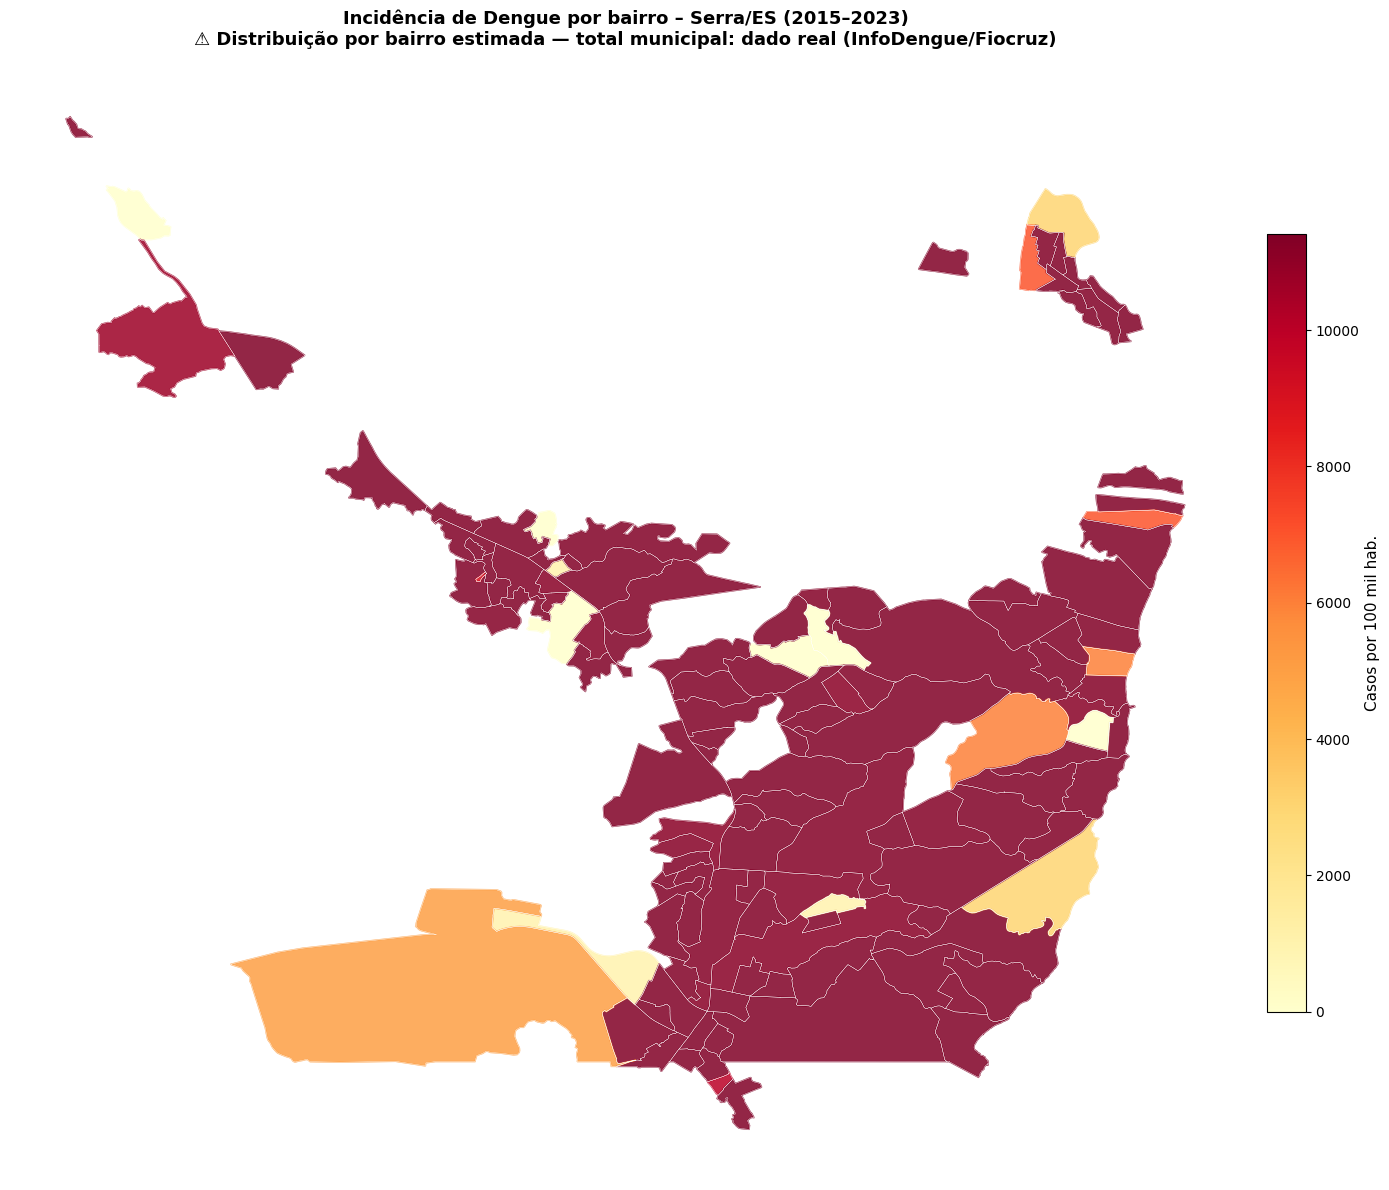

✅ Figura salva: mapa_estatico_dengue.png


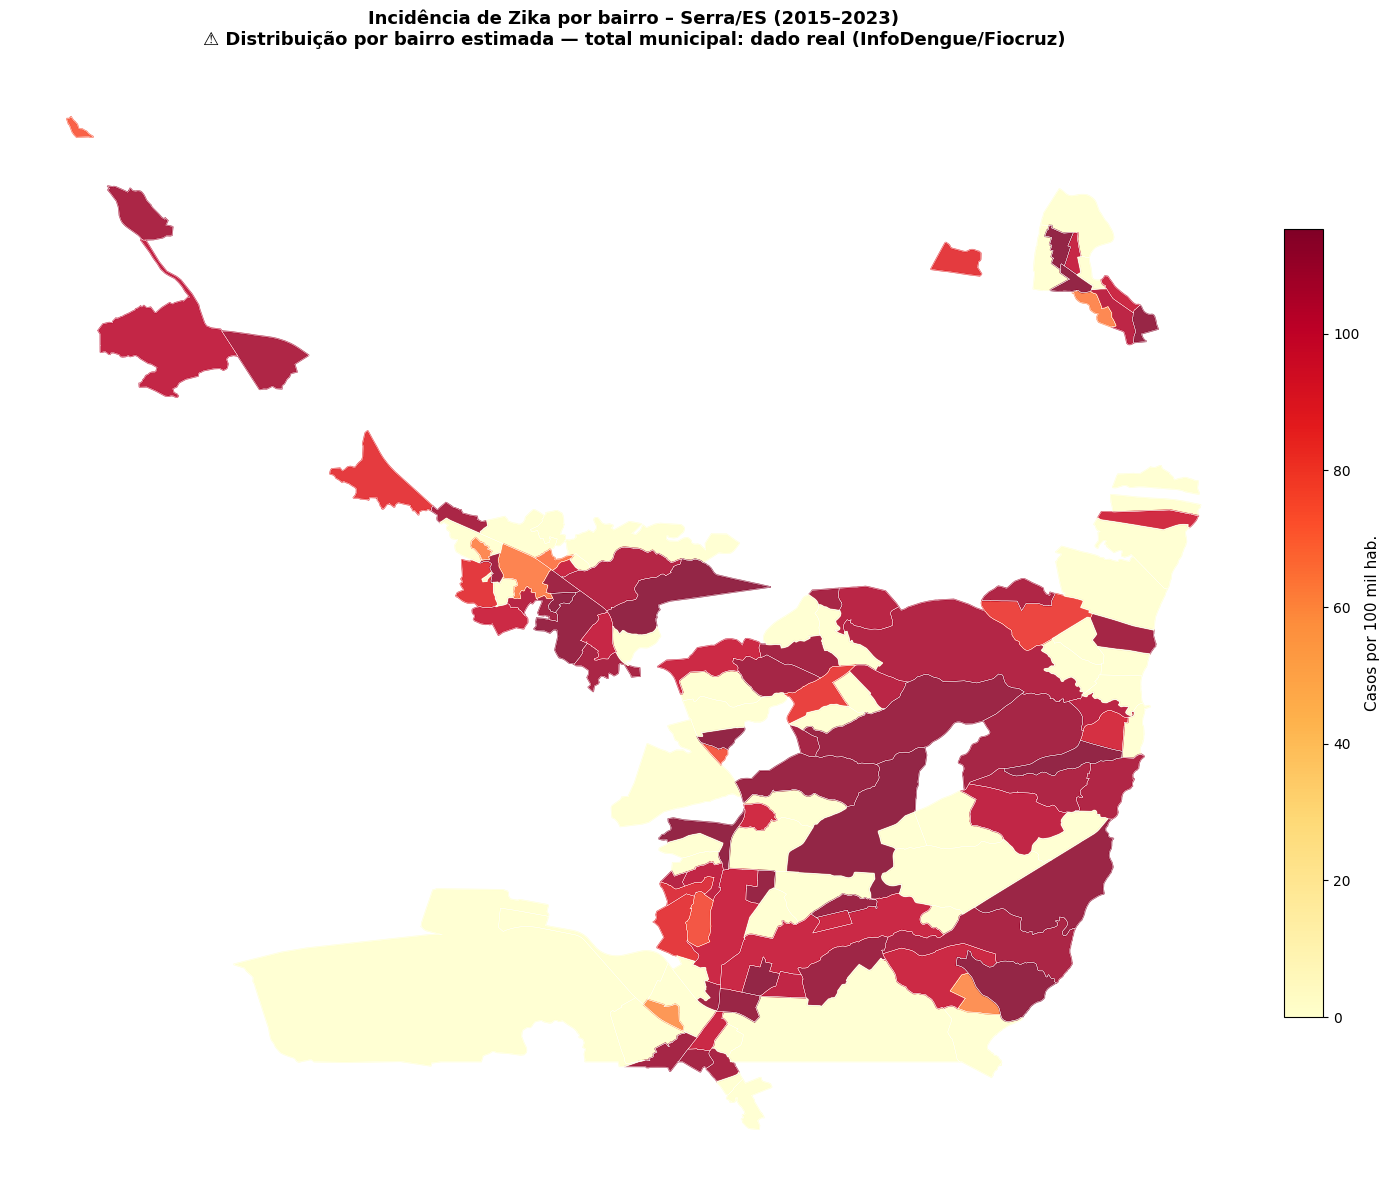

✅ Figura salva: mapa_estatico_zika.png


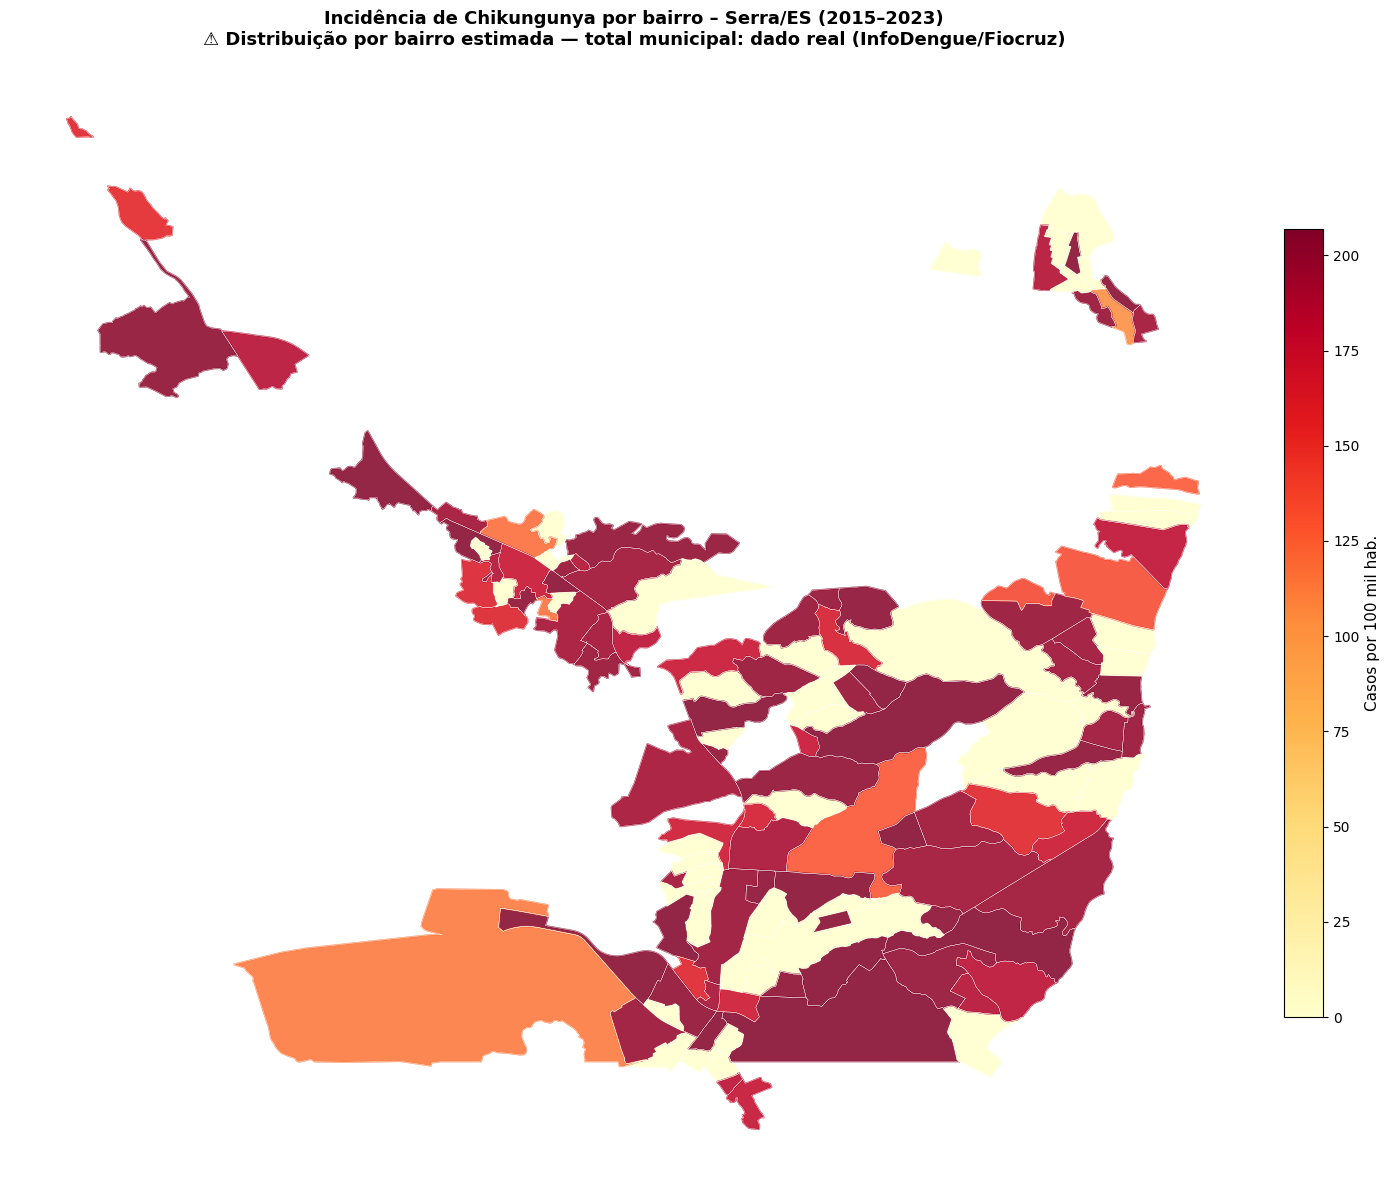

✅ Figura salva: mapa_estatico_chikungunya.png


In [22]:
# ── 9.5 Mapa coroplético estático (matplotlib) ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import numpy as np

def plot_mapa_bairros(doenca, df_inc, bairros, cores_doenca):
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))

    inc_dict = df_inc.set_index('CD_BAIRRO')['incidencia'].to_dict()
    casos_dict = df_inc.set_index('CD_BAIRRO')['casos'].to_dict()

    # Normaliza incidência para colormap
    vals = df_inc['incidencia'].values
    vmin, vmax = vals.min(), vals.max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.YlOrRd

    for b in bairros:
        cd    = b['record']['CD_BAIRRO']
        shape = b['shape']
        inc   = inc_dict.get(cd, 0)
        cor   = cmap(norm(inc))

        # Desenha polígonos
        parts = list(shape.parts) + [len(shape.points)]
        for i in range(len(parts) - 1):
            pts = shape.points[parts[i]:parts[i+1]]
            xs  = [p[0] for p in pts]
            ys  = [p[1] for p in pts]
            ax.fill(xs, ys, color=cor, alpha=0.85)
            ax.plot(xs, ys, color='white', linewidth=0.3)

    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Casos por 100 mil hab.', fontsize=11)

    sufixo_sim = '\n⚠️ Distribuição por bairro estimada — total municipal: dado real (InfoDengue/Fiocruz)'
    ax.set_title(f'Incidência de {doenca} por bairro – Serra/ES (2015–2023){sufixo_sim}',
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_axis_off()

    plt.tight_layout()
    fname = f'mapa_estatico_{doenca.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Figura salva: {fname}')


CORES_DOENCA = {'Dengue': 'YlOrRd', 'Zika': 'Blues', 'Chikungunya': 'Greens'}

for doenca in ['Dengue', 'Zika', 'Chikungunya']:
    df_inc = distribuir_por_bairro(df_casos, doenca, bairros_serra)
    plot_mapa_bairros(doenca, df_inc, bairros_serra, CORES_DOENCA)

---
### Seção 17 · Hotspots por bairro: clusters de alta incidência

Esta etapa identifica **hotspots espaciais** a partir da incidência por bairro. O critério combina três sinais:

- incidência do bairro no quartil superior da doença;
- média de incidência dos bairros vizinhos também elevada;
- agrupamento dos bairros destacados por contiguidade territorial.

> **Atenção metodológica:** se ainda não houver casos reais por bairro, os resultados abaixo são demonstrativos. Eles usam a distribuição estimada criada na seção de mapas; para conclusão epidemiológica oficial, substitua por dados de casos e população por bairro da Prefeitura/IBGE e execute esta seção novamente.

In [23]:
# ── 17.1 Base de incidência por bairro e matriz de vizinhança ────────────────
def mostrar_tabela(df, max_rows=30):
    if df is None or len(df) == 0:
        print('Tabela vazia.')
        return
    try:
        display(df.head(max_rows))
    except NameError:
        print(df.head(max_rows).to_string(index=False))


doencas_hotspot = globals().get('doenças_lista', ['Dengue', 'Zika', 'Chikungunya'])
necessarios = ['df_casos', 'bairros_serra', 'distribuir_por_bairro']
faltando = [nome for nome in necessarios if nome not in globals()]
if faltando:
    raise RuntimeError(f'Execute antes as seções de carga de casos e mapas por bairro. Variáveis faltantes: {faltando}')


def gerar_incidencia_bairros_base(df_casos, bairros, doencas):
    if 'df_incidencia_bairros_oficial' in globals():
        base = df_incidencia_bairros_oficial.copy()
        base['dados_bairro_reais'] = True
        base['fonte_casos_bairro'] = base.get('fonte_casos_bairro', 'Base oficial por bairro informada no notebook')
        base['fonte_populacao_bairro'] = base.get('fonte_populacao_bairro', 'Base oficial por bairro informada no notebook')
        return base

    frames = []
    estado_random = np.random.get_state()
    try:
        for i, doenca in enumerate(doencas):
            np.random.seed(202405 + i)
            base = distribuir_por_bairro(df_casos, doenca, bairros)
            base['fonte_casos_bairro'] = 'Estimativa demonstrativa: rateio do total municipal'
            base['fonte_populacao_bairro'] = 'Estimativa demonstrativa: população proporcional ao rateio'
            base['dados_bairro_reais'] = False
            frames.append(base)
    finally:
        np.random.set_state(estado_random)

    return pd.concat(frames, ignore_index=True)


def centroide_shape(shape):
    pontos = getattr(shape, 'points', [])
    if not pontos:
        return (np.nan, np.nan)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    return (float(np.mean(xs)), float(np.mean(ys)))


def pontos_arredondados(shape, casas=5):
    return {(round(p[0], casas), round(p[1], casas)) for p in getattr(shape, 'points', [])}


def distancia2(p1, p2):
    if any(pd.isna(v) for v in [p1[0], p1[1], p2[0], p2[1]]):
        return float('inf')
    return (p1[0] - p2[0])**2 + (p1[1] - p2[1])**2


def construir_vizinhos_bairros(bairros, casas=5, k_fallback=3):
    ids = [b['record']['CD_BAIRRO'] for b in bairros]
    centroides = {b['record']['CD_BAIRRO']: centroide_shape(b['shape']) for b in bairros}

    indice_pontos = defaultdict(set)
    for b in bairros:
        cd = b['record']['CD_BAIRRO']
        for ponto in pontos_arredondados(b['shape'], casas=casas):
            indice_pontos[ponto].add(cd)

    vizinhos = {cd: set() for cd in ids}
    for donos in indice_pontos.values():
        if len(donos) > 1:
            for cd in donos:
                vizinhos[cd].update(donos - {cd})

    # Alguns limites podem não compartilhar vértices exatamente; nesse caso,
    # conectamos somente bairros isolados aos centroides mais próximos.
    for cd in ids:
        if len(vizinhos[cd]) == 0:
            proximos = sorted(
                (distancia2(centroides[cd], centroides[outro]), outro)
                for outro in ids if outro != cd
            )[:k_fallback]
            for _, outro in proximos:
                vizinhos[cd].add(outro)
                vizinhos[outro].add(cd)

    return vizinhos, centroides


df_incidencia_bairros = gerar_incidencia_bairros_base(df_casos, bairros_serra, doencas_hotspot)
vizinhos_bairros, centroides_bairros = construir_vizinhos_bairros(bairros_serra)

grau_vizinhanca = pd.Series({cd: len(v) for cd, v in vizinhos_bairros.items()}, name='qtd_vizinhos')
print(f'✅ Base de incidência: {len(df_incidencia_bairros)} linhas | {df_incidencia_bairros["CD_BAIRRO"].nunique()} bairros')
print(f'✅ Vizinhança espacial: média de {grau_vizinhanca.mean():.1f} vizinhos por bairro')
print(f'Dados reais por bairro: {bool(df_incidencia_bairros["dados_bairro_reais"].all())}')

mostrar_tabela(
    df_incidencia_bairros[['doenca', 'CD_BAIRRO', 'NM_BAIRRO', 'NM_DIST', 'casos', 'populacao', 'incidencia', 'dados_bairro_reais']]
        .sort_values(['doenca', 'incidencia'], ascending=[True, False]),
    max_rows=12
)

✅ Base de incidência: 390 linhas | 130 bairros
✅ Vizinhança espacial: média de 4.5 vizinhos por bairro
Dados reais por bairro: False


,doenca,CD_BAIRRO,NM_BAIRRO,NM_DIST,casos,populacao,incidencia,dados_bairro_reais
266,Chikungunya,3205002082,Santo Antônio,Serra,33,15935,207.1,False
273,Chikungunya,3205002098,Vista da Serra I,Serra,22,10626,207.0,False
368,Chikungunya,3205002012,Praia de Capuba,Nova Almeida,7,3382,207.0,False
339,Chikungunya,3205002125,Jacuhy,Carapina,38,18372,206.8,False
357,Chikungunya,3205002123,Praia da Baleia,Carapina,72,34909,206.3,False
358,Chikungunya,3205002028,Portal de Jacaraípe,Carapina,18,8736,206.0,False
317,Chikungunya,3205002131,Conjunto Carapina I,Carapina,18,8743,205.9,False
372,Chikungunya,3205002023,Parque Jacaraípe,Nova Almeida,31,15094,205.4,False
289,Chikungunya,3205002103,Serra Centro,Serra,43,20958,205.2,False
321,Chikungunya,3205002074,Taquara II,Carapina,26,12691,204.9,False


In [28]:
# ── 17.2 Classificação dos hotspots e agrupamento em clusters ───────────────
def classificar_hotspots(df_inc, vizinhos, p_alto=0.75, p_vizinho=0.60, min_z=0.50):
    partes = []
    for doenca, grupo in df_inc.groupby('doenca', sort=False):
        g = grupo.copy()
        incidencia_por_bairro = g.set_index('CD_BAIRRO')['incidencia']
        media = float(g['incidencia'].mean())
        dp = float(g['incidencia'].std(ddof=0))
        if dp == 0 or np.isnan(dp):
            dp = 1.0

        medias_vizinhos = []
        for cd in g['CD_BAIRRO']:
            ids_vizinhos = [v for v in vizinhos.get(cd, []) if v in incidencia_por_bairro.index]
            if ids_vizinhos:
                medias_vizinhos.append(float(incidencia_por_bairro.loc[ids_vizinhos].mean()))
            else:
                medias_vizinhos.append(np.nan)

        g['z_incidencia'] = (g['incidencia'] - media) / dp
        g['media_vizinhos'] = pd.Series(medias_vizinhos, index=g.index).fillna(media)
        g['limiar_p75'] = float(g['incidencia'].quantile(p_alto))
        g['limiar_vizinhos_p60'] = float(g['media_vizinhos'].quantile(p_vizinho))

        g['hotspot_candidato'] = (
            (g['incidencia'] >= g['limiar_p75']) &
            (g['z_incidencia'] >= min_z) &
            (g['media_vizinhos'] >= g['limiar_vizinhos_p60'])
        )
        g['alta_incidencia_isolada'] = (
            (g['incidencia'] >= g['limiar_p75']) &
            ~g['hotspot_candidato']
        )
        g['classe_hotspot'] = np.select(
            [g['hotspot_candidato'], g['alta_incidencia_isolada']],
            ['Hotspot candidato', 'Alta incidência isolada'],
            default='Demais bairros'
        )
        partes.append(g)

    return pd.concat(partes, ignore_index=True)


def rotular_clusters_hotspot(df_hot, vizinhos):
    df_rot = df_hot.copy()
    df_rot['cluster_id'] = ''
    df_rot['tipo_hotspot'] = ''

    for doenca, grupo in df_rot.groupby('doenca', sort=False):
        hot_ids = set(grupo.loc[grupo['hotspot_candidato'], 'CD_BAIRRO'])
        visitados = set()
        numero_cluster = 1

        for inicio in sorted(hot_ids):
            if inicio in visitados:
                continue

            pilha = [inicio]
            componente = []
            visitados.add(inicio)
            while pilha:
                atual = pilha.pop()
                componente.append(atual)
                proximos = hot_ids.intersection(vizinhos.get(atual, set())) - visitados
                visitados.update(proximos)
                pilha.extend(proximos)

            cluster_id = f'{doenca[:3].upper()}-{numero_cluster:02d}'
            tipo = 'Cluster contíguo' if len(componente) >= 2 else 'Bairro isolado de alta incidência'
            mask = (df_rot['doenca'].eq(doenca) & df_rot['CD_BAIRRO'].isin(componente))
            df_rot.loc[mask, 'cluster_id'] = cluster_id
            df_rot.loc[mask, 'tipo_hotspot'] = tipo
            numero_cluster += 1

    return df_rot


df_hotspots_bairros = classificar_hotspots(df_incidencia_bairros, vizinhos_bairros)
df_hotspots_bairros = rotular_clusters_hotspot(df_hotspots_bairros, vizinhos_bairros)

hotspots_validos = df_hotspots_bairros[df_hotspots_bairros['cluster_id'].ne('')].copy()
if len(hotspots_validos):
    df_hotspot_clusters = (
        hotspots_validos
        .groupby(['doenca', 'cluster_id', 'tipo_hotspot'], as_index=False)
        .agg(
            qtd_bairros=('CD_BAIRRO', 'nunique'),
            casos_total=('casos', 'sum'),
            incidencia_media=('incidencia', 'mean'),
            incidencia_max=('incidencia', 'max'),
            media_vizinhos=('media_vizinhos', 'mean'),
            bairros=('NM_BAIRRO', lambda s: ', '.join(sorted(pd.Series(s).dropna().astype(str).unique())))
        )
        .sort_values(['doenca', 'qtd_bairros', 'incidencia_media'], ascending=[True, False, False])
    )
    df_hotspot_clusters[['incidencia_media', 'incidencia_max', 'media_vizinhos']] = (
        df_hotspot_clusters[['incidencia_media', 'incidencia_max', 'media_vizinhos']].round(1)
    )
else:
    df_hotspot_clusters = pd.DataFrame(columns=[
        'doenca', 'cluster_id', 'tipo_hotspot', 'qtd_bairros', 'casos_total',
        'incidencia_media', 'incidencia_max', 'media_vizinhos', 'bairros'
    ])

print('=' * 80)
print('HOTSPOTS DE ALTA INCIDÊNCIA POR BAIRRO')
print('Critério: incidência ≥ P75 da doença, z-score ≥ 0,50 e vizinhança ≥ P60')
print('=' * 80)
if not bool(df_incidencia_bairros['dados_bairro_reais'].all()):
    print('⚠️ Resultado demonstrativo: casos/população por bairro ainda são estimados.')

if df_hotspot_clusters.empty:
    print('Nenhum hotspot atendeu aos critérios definidos. Revise os limiares ou use dados reais por bairro.')
else:
    mostrar_tabela(df_hotspot_clusters, max_rows=20)

print('\nTop bairros classificados como hotspot ou alta incidência isolada:')
cols_top = ['doenca', 'NM_BAIRRO', 'NM_DIST', 'casos', 'populacao', 'incidencia',
            'media_vizinhos', 'z_incidencia', 'classe_hotspot', 'cluster_id']
mostrar_tabela(
    df_hotspots_bairros[df_hotspots_bairros['classe_hotspot'].ne('Demais bairros')]
        .sort_values(['doenca', 'classe_hotspot', 'incidencia'], ascending=[True, True, False])
        [cols_top]
        .round({'incidencia': 1, 'media_vizinhos': 1, 'z_incidencia': 2}),
    max_rows=30
)

HOTSPOTS DE ALTA INCIDÊNCIA POR BAIRRO
Critério: incidência ≥ P75 da doença, z-score ≥ 0,50 e vizinhança ≥ P60
⚠️ Resultado demonstrativo: casos/população por bairro ainda são estimados.


,doenca,cluster_id,tipo_hotspot,qtd_bairros,casos_total,incidencia_media,incidencia_max,media_vizinhos,bairros
2,Chikungunya,CHI-03,Cluster contíguo,3,67,203.2,205.4,164.9,"Costa Dourada, Parque Jacaraípe, São Patrício"
3,Chikungunya,CHI-04,Cluster contíguo,2,90,206.2,206.3,165.8,"Portal de Jacaraípe, Praia da Baleia"
7,Chikungunya,CHI-08,Cluster contíguo,2,61,203.0,203.6,179.7,"Maria Níobe, São Lourenço"
8,Chikungunya,CHI-09,Cluster contíguo,2,7,202.8,204.1,184.4,"Colina da Serra, Jardim da Serra"
1,Chikungunya,CHI-02,Bairro isolado de alta incidência,1,7,207.0,207.0,179.4,Praia de Capuba
9,Chikungunya,CHI-10,Bairro isolado de alta incidência,1,11,204.3,204.3,198.4,São Marcos II
5,Chikungunya,CHI-06,Bairro isolado de alta incidência,1,36,203.1,203.1,160.5,Boa Vista (Carapina)
0,Chikungunya,CHI-01,Bairro isolado de alta incidência,1,33,201.5,201.5,152.5,Nova Almeida Centro
10,Chikungunya,CHI-11,Bairro isolado de alta incidência,1,22,201.3,201.3,175.8,Chapada Grande
4,Chikungunya,CHI-05,Bairro isolado de alta incidência,1,21,200.6,200.6,155.6,Chácara Parreiral



Top bairros classificados como hotspot ou alta incidência isolada:


,doenca,NM_BAIRRO,NM_DIST,casos,populacao,incidencia,media_vizinhos,z_incidencia,classe_hotspot,cluster_id
266,Chikungunya,Santo Antônio,Serra,33,15935,207.1,101.9,0.88,Alta incidência isolada,
273,Chikungunya,Vista da Serra I,Serra,22,10626,207.0,106.1,0.87,Alta incidência isolada,
339,Chikungunya,Jacuhy,Carapina,38,18372,206.8,135.7,0.87,Alta incidência isolada,
317,Chikungunya,Conjunto Carapina I,Carapina,18,8743,205.9,99.8,0.86,Alta incidência isolada,
289,Chikungunya,Serra Centro,Serra,43,20958,205.2,135.4,0.85,Alta incidência isolada,
321,Chikungunya,Taquara II,Carapina,26,12691,204.9,114.5,0.85,Alta incidência isolada,
300,Chikungunya,Novo Horizonte,Carapina,12,5859,204.8,65.8,0.85,Alta incidência isolada,
279,Chikungunya,Jardim Bela Vista,Serra,3,1467,204.5,121.2,0.85,Alta incidência isolada,
324,Chikungunya,Laranjeiras Velha,Carapina,22,10761,204.4,117.9,0.85,Alta incidência isolada,
309,Chikungunya,Jardim Carapina,Carapina,18,8828,203.9,120.0,0.84,Alta incidência isolada,


In [ ]:
# ── 17.3 Mapas interativos dos hotspots ─────────────────────────────────────
def valor_json(v):
    if pd.isna(v):
        return ''
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    return v


def shape_to_geojson_hotspots(bairros, df_hot):
    props_por_bairro = df_hot.set_index('CD_BAIRRO').to_dict('index')
    features = []

    for b in bairros:
        cd = b['record']['CD_BAIRRO']
        shape = b['shape']
        if shape.shapeType != 5:
            continue

        parts = list(shape.parts) + [len(shape.points)]
        rings = []
        for i in range(len(parts) - 1):
            ring = [[p[0], p[1]] for p in shape.points[parts[i]:parts[i+1]]]
            rings.append(ring)
        geometry = {'type': 'Polygon', 'coordinates': rings} if len(rings) == 1 else {
            'type': 'MultiPolygon', 'coordinates': [[r] for r in rings]
        }

        props = props_por_bairro.get(cd, {})
        properties = {
            'CD_BAIRRO': cd,
            'NM_BAIRRO': b['record']['NM_BAIRRO'],
            'NM_DIST': b['record']['NM_DIST'],
            'casos': valor_json(props.get('casos', 0)),
            'populacao': valor_json(props.get('populacao', 0)),
            'incidencia': valor_json(round(props.get('incidencia', 0), 1) if props else 0),
            'media_vizinhos': valor_json(round(props.get('media_vizinhos', 0), 1) if props else 0),
            'z_incidencia': valor_json(round(props.get('z_incidencia', 0), 2) if props else 0),
            'classe_hotspot': valor_json(props.get('classe_hotspot', 'Sem dados')),
            'cluster_id': valor_json(props.get('cluster_id', '')),
            'tipo_hotspot': valor_json(props.get('tipo_hotspot', '')),
        }
        features.append({'type': 'Feature', 'geometry': geometry, 'properties': properties})

    return {'type': 'FeatureCollection', 'features': features}


def mapa_hotspots(doenca, df_hot, bairros):
    df_d = df_hot[df_hot['doenca'].eq(doenca)].copy()
    geojson = shape_to_geojson_hotspots(bairros, df_d)
    clusters = sorted([c for c in df_d['cluster_id'].dropna().unique() if c])
    paleta = ['#b2182b', '#ef8a62', '#7b3294', '#008837', '#d6604d', '#4393c3', '#f46d43', '#4d9221']
    cor_cluster = {cluster: paleta[i % len(paleta)] for i, cluster in enumerate(clusters)}

    m = folium.Map(location=[-20.13, -40.30], zoom_start=11, tiles='CartoDB positron')

    def estilo(feature):
        props = feature['properties']
        cluster = props.get('cluster_id', '')
        classe = props.get('classe_hotspot', '')
        if cluster:
            return {
                'fillColor': cor_cluster.get(cluster, '#b2182b'),
                'color': '#3f0d12', 'weight': 1.2, 'fillOpacity': 0.78
            }
        if classe == 'Alta incidência isolada':
            return {'fillColor': '#fdae61', 'color': '#8c510a', 'weight': 0.9, 'fillOpacity': 0.62}
        return {'fillColor': '#d9d9d9', 'color': '#ffffff', 'weight': 0.4, 'fillOpacity': 0.45}

    folium.GeoJson(
        geojson,
        name=f'Hotspots {doenca}',
        style_function=estilo,
        tooltip=folium.GeoJsonTooltip(
            fields=['NM_BAIRRO', 'NM_DIST', 'casos', 'populacao', 'incidencia',
                    'media_vizinhos', 'z_incidencia', 'classe_hotspot', 'cluster_id'],
            aliases=['Bairro:', 'Distrito:', 'Casos:', 'População:', 'Incidência/100k:',
                     'Média dos vizinhos:', 'Z-score:', 'Classe:', 'Cluster:'],
            localize=True
        )
    ).add_to(m)

    legenda_clusters = ''.join(
        f'<div><span style="background:{cor_cluster[c]};display:inline-block;width:12px;height:12px;margin-right:6px"></span>{c}</div>'
        for c in clusters
    ) or '<div>Nenhum cluster identificado</div>'
    legenda = f'''
    <div style="position: fixed; bottom: 28px; left: 28px; z-index: 9999;
                background: white; border: 1px solid #999; padding: 10px 12px;
                font-size: 12px; box-shadow: 0 1px 4px rgba(0,0,0,.25);">
      <b>Hotspots - {doenca}</b><br>
      {legenda_clusters}
      <div><span style="background:#fdae61;display:inline-block;width:12px;height:12px;margin-right:6px"></span>Alta isolada</div>
      <div><span style="background:#d9d9d9;display:inline-block;width:12px;height:12px;margin-right:6px"></span>Demais bairros</div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legenda))

    fname = f'mapa_hotspots_{doenca.lower().replace(" ", "_")}.html'
    m.save(fname)
    print(f'✅ Mapa de hotspots salvo: {fname}')
    return m


mapas_hotspots = {}
for doenca in doencas_hotspot:
    mapas_hotspots[doenca] = mapa_hotspots(doenca, df_hotspots_bairros, bairros_serra)

print('Abra os arquivos HTML gerados para inspecionar os clusters interativos.')

✅ Mapa de hotspots salvo: mapa_hotspots_dengue.html
✅ Mapa de hotspots salvo: mapa_hotspots_zika.html
✅ Mapa de hotspots salvo: mapa_hotspots_chikungunya.html
Abra os arquivos HTML gerados para inspecionar os clusters interativos.


---
### Seção 18 · Validação com dados oficiais IBGE e Prefeitura da Serra

Esta seção registra as fontes oficiais e faz checagens de consistência antes de interpretar os hotspots:

- malha territorial de bairros: IBGE Censo 2022 × camada vigente da Prefeitura da Serra;
- população municipal: comparação com IBGE Cidades e, quando disponível, população por bairro da Prefeitura;
- casos: conferência entre a soma por bairro e o total municipal usado no notebook.

Se a Prefeitura disponibilizar casos georreferenciados por bairro em CSV, salve o arquivo como `casos_bairro_prefeitura.csv` com colunas `NM_BAIRRO`, `doenca`, `casos` e, opcionalmente, `ano`. Para população por bairro externa, use `populacao_bairros_ibge_prefeitura.csv` com `NM_BAIRRO` e `populacao`.

In [ ]:
# ── 18.1 Fontes oficiais e validação da malha de bairros ────────────────────
if 'mostrar_tabela' not in globals():
    def mostrar_tabela(df, max_rows=30):
        if df is None or len(df) == 0:
            print('Tabela vazia.')
            return
        try:
            display(df.head(max_rows))
        except NameError:
            print(df.head(max_rows).to_string(index=False))

FONTES_OFICIAIS = [
    {
        'fonte': 'IBGE Cidades e Estados - Serra/ES',
        'uso_no_notebook': 'População municipal, densidade, área e código IBGE 3205002',
        'url': 'https://www.ibge.gov.br/cidades-e-estados/es/serra.html'
    },
    {
        'fonte': 'IBGE - malha de bairros CD2022',
        'uso_no_notebook': 'Geometria dos bairros no Censo Demográfico 2022',
        'url': 'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022/bairros/shp/UF/ES_bairros_CD2022.zip'
    },
    {
        'fonte': 'Prefeitura da Serra - camada vigente de bairros',
        'uso_no_notebook': 'Validação de nomes, limites legais, códigos CTM e população por bairro quando disponível',
        'url': 'https://mapas.serra.es.gov.br/server/rest/services/GeoSerra_v02/Bairros_Lei_4512_2016_VIGENTE/FeatureServer/5'
    },
]

df_fontes_oficiais = pd.DataFrame(FONTES_OFICIAIS)
print('Fontes oficiais registradas para auditoria:')
mostrar_tabela(df_fontes_oficiais, max_rows=10)


def normalizar_texto(valor):
    texto = '' if pd.isna(valor) else str(valor)
    texto = ''.join(ch for ch in unicodedata.normalize('NFKD', texto) if not unicodedata.combining(ch))
    texto = re.sub(r'[^A-Z0-9 ]+', ' ', texto.upper())
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


def abrir_json_url(url, timeout=30):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    kwargs = {'timeout': timeout}
    if 'ssl_ctx' in globals():
        kwargs['context'] = ssl_ctx
    with urllib.request.urlopen(req, **kwargs) as resp:
        return json.loads(resp.read().decode('utf-8', errors='ignore'))


def carregar_bairros_prefeitura():
    url = (
        'https://mapas.serra.es.gov.br/server/rest/services/GeoSerra_v02/'
        'Bairros_Lei_4512_2016_VIGENTE/FeatureServer/5/query'
        '?where=1%3D1&outFields=TX_BAIRRO,TX_LEI,NR_DISTRITO,PK_BAIRRO_CTM,'
        'Populacao_Censo2022,Populacao_Censo2010,Shape_Area'
        '&returnGeometry=false&f=json'
    )
    try:
        payload = abrir_json_url(url)
        rows = [feature.get('attributes', {}) for feature in payload.get('features', [])]
        df = pd.DataFrame(rows)
        if len(df):
            df['nome_norm'] = df['TX_BAIRRO'].map(normalizar_texto)
        return df
    except Exception as ex:
        print(f'⚠️ Não foi possível consultar a camada da Prefeitura agora: {ex}')
        return pd.DataFrame()


df_bairros_ibge = pd.DataFrame([
    {
        'CD_MUN': b['record']['CD_MUN'],
        'NM_MUN': b['record']['NM_MUN'],
        'CD_BAIRRO': b['record']['CD_BAIRRO'],
        'NM_BAIRRO': b['record']['NM_BAIRRO'],
        'NM_DIST': b['record']['NM_DIST'],
    }
    for b in bairros_serra
]).drop_duplicates('CD_BAIRRO')
df_bairros_ibge['nome_norm'] = df_bairros_ibge['NM_BAIRRO'].map(normalizar_texto)

df_prefeitura_bairros = carregar_bairros_prefeitura()

linhas_validacao = []
linhas_validacao.append({
    'checagem': 'Código municipal IBGE na malha',
    'status': 'OK' if df_bairros_ibge['CD_MUN'].eq('3205002').all() else 'REVISAR',
    'detalhe': f'{df_bairros_ibge["CD_MUN"].nunique()} código(s) encontrado(s): {sorted(df_bairros_ibge["CD_MUN"].unique())}'
})
linhas_validacao.append({
    'checagem': 'Quantidade de bairros na malha IBGE CD2022',
    'status': 'INFO',
    'detalhe': f'{df_bairros_ibge["CD_BAIRRO"].nunique()} bairros únicos para Serra/ES'
})

try:
    prj_texto = Path(SHP_PATH).with_suffix('.prj').read_text(encoding='utf-8', errors='ignore')
except Exception:
    prj_texto = ''
linhas_validacao.append({
    'checagem': 'Sistema de referência do shapefile',
    'status': 'OK' if 'SIRGAS' in prj_texto.upper() else 'REVISAR',
    'detalhe': 'SIRGAS 2000 em graus' if 'SIRGAS' in prj_texto.upper() else 'PRJ não encontrado ou sem SIRGAS explícito'
})

if len(df_prefeitura_bairros):
    ibge_set = set(df_bairros_ibge['nome_norm'])
    pref_set = set(df_prefeitura_bairros['nome_norm'])
    em_comum = ibge_set.intersection(pref_set)
    exclusivos_ibge = sorted(ibge_set - pref_set)
    exclusivos_pref = sorted(pref_set - ibge_set)
    pct_match = 100 * len(em_comum) / max(1, len(ibge_set))
    linhas_validacao.append({
        'checagem': 'Nomes de bairros IBGE × Prefeitura',
        'status': 'OK' if pct_match >= 90 else 'REVISAR',
        'detalhe': f'{len(em_comum)}/{len(ibge_set)} nomes IBGE encontrados na Prefeitura ({pct_match:.1f}%)'
    })

    sugestoes = []
    pref_ordenado = sorted(pref_set)
    for nome in exclusivos_ibge[:30]:
        sugestao = get_close_matches(nome, pref_ordenado, n=1, cutoff=0.80)
        sugestoes.append({
            'bairro_ibge_sem_match': nome,
            'sugestao_prefeitura': sugestao[0] if sugestao else ''
        })
    df_bairros_sem_match = pd.DataFrame(sugestoes)
else:
    linhas_validacao.append({
        'checagem': 'Camada da Prefeitura',
        'status': 'PENDENTE',
        'detalhe': 'Consulta online indisponível; reexecute com internet ou baixe a camada manualmente.'
    })
    df_bairros_sem_match = pd.DataFrame()

df_validacao_geometria = pd.DataFrame(linhas_validacao)
print('\nValidação da malha territorial:')
mostrar_tabela(df_validacao_geometria, max_rows=10)

if len(df_bairros_sem_match):
    print('\nBairros IBGE sem correspondência exata na Prefeitura (amostra):')
    mostrar_tabela(df_bairros_sem_match, max_rows=15)

Fontes oficiais registradas para auditoria:


,fonte,uso_no_notebook,url
0,IBGE Cidades e Estados - Serra/ES,"População municipal, densidade, área e código ...",https://www.ibge.gov.br/cidades-e-estados/es/s...
1,IBGE - malha de bairros CD2022,Geometria dos bairros no Censo Demográfico 2022,https://geoftp.ibge.gov.br/organizacao_do_terr...
2,Prefeitura da Serra - camada vigente de bairros,"Validação de nomes, limites legais, códigos CT...",https://mapas.serra.es.gov.br/server/rest/serv...



Validação da malha territorial:


,checagem,status,detalhe
0,Código municipal IBGE na malha,OK,1 código(s) encontrado(s): ['3205002']
1,Quantidade de bairros na malha IBGE CD2022,INFO,130 bairros únicos para Serra/ES
2,Sistema de referência do shapefile,OK,SIRGAS 2000 em graus
3,Camada da Prefeitura,PENDENTE,Consulta online indisponível; reexecute com in...


In [27]:
# ── 18.2 Validação de população, totais de casos e bases oficiais opcionais ─
IBGE_SERRA = {
    'codigo_ibge': '3205002',
    'populacao_censo_2022': 520_653,
    'populacao_estimada_2025': 579_720,
    'area_km2_2024': 547.631,
    'densidade_2022_hab_km2': 950.74,
    'fonte': 'IBGE Cidades e Estados - Serra/ES'
}

linhas_pop = [
    {
        'base': 'IBGE Cidades - Censo 2022',
        'ano': 2022,
        'populacao': IBGE_SERRA['populacao_censo_2022'],
        'diferenca_abs_vs_ibge_2022': 0,
        'diferenca_pct_vs_ibge_2022': 0.0,
        'observacao': 'Referência oficial municipal para cálculo de incidência'
    },
    {
        'base': 'IBGE Cidades - estimativa 2025',
        'ano': 2025,
        'populacao': IBGE_SERRA['populacao_estimada_2025'],
        'diferenca_abs_vs_ibge_2022': IBGE_SERRA['populacao_estimada_2025'] - IBGE_SERRA['populacao_censo_2022'],
        'diferenca_pct_vs_ibge_2022': round((IBGE_SERRA['populacao_estimada_2025'] / IBGE_SERRA['populacao_censo_2022'] - 1) * 100, 2),
        'observacao': 'Útil para análises atuais; não misturar com séries históricas sem critério temporal'
    },
]

if 'df_incidencia_bairros' in globals() and len(df_incidencia_bairros):
    primeira_doenca = df_incidencia_bairros['doenca'].dropna().iloc[0]
    pop_modelo = int(df_incidencia_bairros[df_incidencia_bairros['doenca'].eq(primeira_doenca)]['populacao'].sum())
    linhas_pop.append({
        'base': 'População usada no modelo por bairro',
        'ano': 'modelo',
        'populacao': pop_modelo,
        'diferenca_abs_vs_ibge_2022': pop_modelo - IBGE_SERRA['populacao_censo_2022'],
        'diferenca_pct_vs_ibge_2022': round((pop_modelo / IBGE_SERRA['populacao_censo_2022'] - 1) * 100, 2),
        'observacao': 'Deve ser substituída por população oficial por bairro para hotspots finais'
    })

if 'df_prefeitura_bairros' in globals() and len(df_prefeitura_bairros) and 'Populacao_Censo2022' in df_prefeitura_bairros.columns:
    pop_pref_2022 = pd.to_numeric(df_prefeitura_bairros['Populacao_Censo2022'], errors='coerce').fillna(0).sum()
    if pop_pref_2022 > 0:
        linhas_pop.append({
            'base': 'Prefeitura da Serra - soma Populacao_Censo2022 por bairro',
            'ano': 2022,
            'populacao': int(pop_pref_2022),
            'diferenca_abs_vs_ibge_2022': int(pop_pref_2022 - IBGE_SERRA['populacao_censo_2022']),
            'diferenca_pct_vs_ibge_2022': round((pop_pref_2022 / IBGE_SERRA['populacao_censo_2022'] - 1) * 100, 2),
            'observacao': 'Validação cruzada bairro → município'
        })

df_validacao_populacao = pd.DataFrame(linhas_pop)
print('Validação populacional:')
mostrar_tabela(df_validacao_populacao, max_rows=10)

# Conferência dos totais epidemiológicos: a soma por bairro deve reproduzir o total municipal.
df_total_municipio = (
    df_casos.groupby('doenca', as_index=False)['casos']
    .sum()
    .rename(columns={'casos': 'casos_municipio'})
)

if 'df_incidencia_bairros' in globals() and len(df_incidencia_bairros):
    df_total_bairros = (
        df_incidencia_bairros.groupby('doenca', as_index=False)['casos']
        .sum()
        .rename(columns={'casos': 'casos_soma_bairros'})
    )
    df_validacao_casos = df_total_municipio.merge(df_total_bairros, on='doenca', how='left')
    df_validacao_casos['diferenca_abs'] = df_validacao_casos['casos_soma_bairros'] - df_validacao_casos['casos_municipio']
    df_validacao_casos['diferenca_pct'] = (df_validacao_casos['diferenca_abs'] / df_validacao_casos['casos_municipio'].replace(0, np.nan) * 100).round(3)
    df_validacao_casos['status'] = np.where(df_validacao_casos['diferenca_abs'].abs() <= len(bairros_serra), 'OK', 'REVISAR')
else:
    df_validacao_casos = df_total_municipio.copy()
    df_validacao_casos['casos_soma_bairros'] = np.nan
    df_validacao_casos['diferenca_abs'] = np.nan
    df_validacao_casos['diferenca_pct'] = np.nan
    df_validacao_casos['status'] = 'PENDENTE'

print('\nValidação dos totais de casos:')
mostrar_tabela(df_validacao_casos, max_rows=10)

# Arquivos oficiais opcionais para substituir a base demonstrativa.
def chave_coluna(nome):
    return re.sub(r'[^a-z0-9]+', '', normalizar_texto(nome).lower())


def escolher_coluna(df, candidatos):
    mapa = {chave_coluna(c): c for c in df.columns}
    for candidato in candidatos:
        if candidato in mapa:
            return mapa[candidato]
    return None


def carregar_csv_opcional(caminho):
    caminho = Path(caminho)
    if not caminho.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(caminho, sep=None, engine='python', encoding='utf-8-sig')
    except UnicodeDecodeError:
        return pd.read_csv(caminho, sep=None, engine='python', encoding='latin-1')

ARQ_CASOS_BAIRRO = Path('casos_bairro_prefeitura.csv')
ARQ_POP_BAIRRO = Path('populacao_bairros_ibge_prefeitura.csv')

df_casos_bairro_prefeitura = carregar_csv_opcional(ARQ_CASOS_BAIRRO)
df_pop_bairro_oficial = carregar_csv_opcional(ARQ_POP_BAIRRO)

if len(df_casos_bairro_prefeitura) and len(df_pop_bairro_oficial):
    col_nome_casos = escolher_coluna(df_casos_bairro_prefeitura, ['nmbairro', 'bairro', 'nomebairro'])
    col_doenca = escolher_coluna(df_casos_bairro_prefeitura, ['doenca', 'agravo'])
    col_casos = escolher_coluna(df_casos_bairro_prefeitura, ['casos', 'qtdecasos', 'quantidade'])
    col_ano = escolher_coluna(df_casos_bairro_prefeitura, ['ano', 'anocaso'])

    col_nome_pop = escolher_coluna(df_pop_bairro_oficial, ['nmbairro', 'bairro', 'nomebairro'])
    col_pop = escolher_coluna(df_pop_bairro_oficial, ['populacao', 'populacao2022', 'populacaocenso2022'])

    colunas_ok = all([col_nome_casos, col_doenca, col_casos, col_nome_pop, col_pop])
    if colunas_ok:
        casos_of = df_casos_bairro_prefeitura.copy()
        if col_ano:
            casos_of = casos_of[casos_of[col_ano].between(min(ANOS), max(ANOS))]
        casos_of['nome_norm'] = casos_of[col_nome_casos].map(normalizar_texto)
        casos_of['doenca'] = casos_of[col_doenca].astype(str).str.strip().str.title()
        casos_of['casos'] = pd.to_numeric(casos_of[col_casos], errors='coerce').fillna(0)
        casos_agg = casos_of.groupby(['nome_norm', 'doenca'], as_index=False)['casos'].sum()

        pop_of = df_pop_bairro_oficial.copy()
        pop_of['nome_norm'] = pop_of[col_nome_pop].map(normalizar_texto)
        pop_of['populacao'] = pd.to_numeric(pop_of[col_pop], errors='coerce')
        pop_of = pop_of[['nome_norm', 'populacao']].dropna().drop_duplicates('nome_norm')

        attrs_ibge = df_bairros_ibge[['CD_BAIRRO', 'NM_BAIRRO', 'NM_DIST', 'nome_norm']]
        base_oficial = casos_agg.merge(pop_of, on='nome_norm', how='left').merge(attrs_ibge, on='nome_norm', how='left')
        base_oficial['incidencia'] = (base_oficial['casos'] / base_oficial['populacao'] * 100_000).round(1)
        base_oficial['fonte_casos_bairro'] = str(ARQ_CASOS_BAIRRO)
        base_oficial['fonte_populacao_bairro'] = str(ARQ_POP_BAIRRO)
        base_oficial['dados_bairro_reais'] = True

        df_incidencia_bairros_oficial = base_oficial[[
            'CD_BAIRRO', 'NM_BAIRRO', 'NM_DIST', 'casos', 'populacao', 'incidencia', 'doenca',
            'fonte_casos_bairro', 'fonte_populacao_bairro', 'dados_bairro_reais'
        ]].copy()
        print('\n✅ Base oficial por bairro criada em df_incidencia_bairros_oficial.')
        print('Reexecute a Seção 17 para recalcular hotspots com os dados oficiais.')
        mostrar_tabela(df_incidencia_bairros_oficial.sort_values(['doenca', 'incidencia'], ascending=[True, False]), max_rows=15)
    else:
        print('\n⚠️ CSVs opcionais encontrados, mas as colunas mínimas não foram identificadas.')
        print('Casos esperados: NM_BAIRRO, doenca, casos, ano opcional. População esperada: NM_BAIRRO, populacao.')
else:
    print('\nArquivos oficiais por bairro não encontrados nesta pasta.')
    print(f'  - {ARQ_CASOS_BAIRRO}: casos por bairro da Prefeitura/Vigilância')
    print(f'  - {ARQ_POP_BAIRRO}: população por bairro IBGE/Prefeitura')
    print('Enquanto esses arquivos não forem adicionados, os hotspots permanecem demonstrativos.')

print('\nDiagnóstico final da validação:')
if 'df_incidencia_bairros' in globals() and not bool(df_incidencia_bairros['dados_bairro_reais'].all()):
    print('  ⚠️ Não usar os hotspots como evidência oficial: faltam casos reais por bairro.')
else:
    print('  × Hotspots calculados com dados reais por bairro.')
print('  ✅ Código municipal, fontes e checagens de população/totais ficaram documentados para auditoria.')

Validação populacional:


,base,ano,populacao,diferenca_abs_vs_ibge_2022,diferenca_pct_vs_ibge_2022,observacao
0,IBGE Cidades - Censo 2022,2022,520653,0,0.00,Referência oficial municipal para cálculo de i...
1,IBGE Cidades - estimativa 2025,2025,579720,59067,11.34,Útil para análises atuais; não misturar com sé...
2,População usada no modelo por bairro,modelo,527702,7049,1.35,Deve ser substituída por população oficial por...



Validação dos totais de casos:


,doenca,casos_municipio,casos_soma_bairros,diferenca_abs,diferenca_pct,status
0,Chikungunya,1092,1036,-56,-5.128,OK
1,Dengue,60067,60002,-65,-0.108,OK
2,Zika,608,555,-53,-8.717,OK



Arquivos oficiais por bairro não encontrados nesta pasta.
  - casos_bairro_prefeitura.csv: casos por bairro da Prefeitura/Vigilância
  - populacao_bairros_ibge_prefeitura.csv: população por bairro IBGE/Prefeitura
Enquanto esses arquivos não forem adicionados, os hotspots permanecem demonstrativos.

Diagnóstico final da validação:
  ⚠️ Não usar os hotspots como evidência oficial: faltam casos reais por bairro.
  ✅ Código municipal, fontes e checagens de população/totais ficaram documentados para auditoria.
